In [71]:
import os
import numpy as np
import librosa
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from hmmlearn import hmm
import pickle
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

## Exploratory Data Analysis (EDA)

Analisis karakteristik dataset audio untuk menentukan strategi preprocessing yang optimal.

In [72]:
class AudioEDA:
    def __init__(self, sr=16000, min_duration=0.5):
        self.sr = sr
        self.min_duration = min_duration
        self.stats = {
            'filename': [],
            'original_sr': [],
            'channels': [],
            'original_duration': [],
            'trimmed_duration': [],
            'peak_amplitude': [],
            'rms_energy': [],
            'silence_ratio': [],
            'spectral_centroid_mean': [],
            'labels': []
        }
        self.invalid_files = []
    
    def analyze_folder(self, folder, label):
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]
        
        for filename in files:
            filepath = os.path.join(folder, filename)
            try:
                audio_raw, original_sr = librosa.load(filepath, sr=None, mono=False)
                
                if audio_raw.ndim > 1:
                    n_channels = audio_raw.shape[0]
                    audio = librosa.to_mono(audio_raw)
                else:
                    n_channels = 1
                    audio = audio_raw
                
                if original_sr != self.sr:
                    audio = librosa.resample(audio, orig_sr=original_sr, target_sr=self.sr)
                
                original_duration = len(audio) / self.sr
                audio_trimmed, _ = librosa.effects.trim(audio, top_db=20)
                trimmed_duration = len(audio_trimmed) / self.sr
                
                if trimmed_duration < self.min_duration:
                    self.invalid_files.append({
                        'filename': filename,
                        'label': label,
                        'reason': f'Duration too short ({trimmed_duration:.2f}s < {self.min_duration}s)'
                    })
                    continue
                
                peak_amplitude = np.max(np.abs(audio_trimmed))
                rms_energy = np.sqrt(np.mean(audio_trimmed**2))
                silence_ratio = 1 - (len(audio_trimmed) / len(audio))
                spectral_centroid = librosa.feature.spectral_centroid(y=audio_trimmed, sr=self.sr)
                
                self.stats['filename'].append(filename)
                self.stats['original_sr'].append(original_sr)
                self.stats['channels'].append(n_channels)
                self.stats['original_duration'].append(original_duration)
                self.stats['trimmed_duration'].append(trimmed_duration)
                self.stats['peak_amplitude'].append(peak_amplitude)
                self.stats['rms_energy'].append(rms_energy)
                self.stats['silence_ratio'].append(silence_ratio)
                self.stats['spectral_centroid_mean'].append(np.mean(spectral_centroid))
                self.stats['labels'].append(label)
            except Exception as e:
                self.invalid_files.append({
                    'filename': filename,
                    'label': label,
                    'reason': f'Error: {str(e)}'
                })
    
    def analyze_all(self, folders_with_labels):
        for folder, label in folders_with_labels:
            self.analyze_folder(folder, label)
        
        df = pd.DataFrame(self.stats)
        return df
    
    def plot_comprehensive_analysis(self, df):
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
        
        ax1 = fig.add_subplot(gs[0, 0])
        normal_data = df[df['labels']=='normal']['channels'].value_counts()
        tb_data = df[df['labels']=='tb']['channels'].value_counts()
        x = np.arange(len(normal_data))
        width = 0.35
        ax1.bar(x - width/2, normal_data.values, width, label='Normal', alpha=0.7)
        ax1.bar(x + width/2, tb_data.values, width, label='TB', alpha=0.7)
        ax1.set_xlabel('Number of Channels')
        ax1.set_ylabel('Count')
        ax1.set_title('1. Audio Channels Distribution')
        ax1.set_xticks(x)
        ax1.set_xticklabels(normal_data.index)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2 = fig.add_subplot(gs[0, 1])
        normal_sr = df[df['labels']=='normal']['original_sr'].value_counts()
        tb_sr = df[df['labels']=='tb']['original_sr'].value_counts()
        all_sr = sorted(set(normal_sr.index) | set(tb_sr.index))
        x = np.arange(len(all_sr))
        ax2.bar(x - width/2, [normal_sr.get(sr, 0) for sr in all_sr], width, label='Normal', alpha=0.7)
        ax2.bar(x + width/2, [tb_sr.get(sr, 0) for sr in all_sr], width, label='TB', alpha=0.7)
        ax2.set_xlabel('Sample Rate (Hz)')
        ax2.set_ylabel('Count')
        ax2.set_title('2. Sample Rate Distribution')
        ax2.set_xticks(x)
        ax2.set_xticklabels([f'{int(sr/1000)}k' for sr in all_sr], rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.hist([df[df['labels']=='normal']['silence_ratio'], 
                  df[df['labels']=='tb']['silence_ratio']], 
                 label=['Normal', 'TB'], bins=20, alpha=0.7)
        ax3.set_xlabel('Silence Ratio')
        ax3.set_ylabel('Frequency')
        ax3.set_title('3. Silence Ratio Distribution')
        ax3.axvline(x=0.3, color='r', linestyle='--', linewidth=1, alpha=0.5)
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        ax4 = fig.add_subplot(gs[0, 3])
        ax4.hist([df[df['labels']=='normal']['trimmed_duration'], 
                  df[df['labels']=='tb']['trimmed_duration']], 
                 label=['Normal', 'TB'], bins=20, alpha=0.7)
        ax4.set_xlabel('Duration (seconds)')
        ax4.set_ylabel('Frequency')
        ax4.set_title('4. Duration After Trimming')
        ax4.axvline(x=0.5, color='r', linestyle='--', linewidth=1, label='Min threshold', alpha=0.5)
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        ax5 = fig.add_subplot(gs[1, 0])
        ax5.hist([df[df['labels']=='normal']['peak_amplitude'], 
                  df[df['labels']=='tb']['peak_amplitude']], 
                 label=['Normal', 'TB'], bins=20, alpha=0.7)
        ax5.set_xlabel('Peak Amplitude')
        ax5.set_ylabel('Frequency')
        ax5.set_title('5. Peak Amplitude Distribution')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
        
        ax6 = fig.add_subplot(gs[1, 1])
        ax6.hist([df[df['labels']=='normal']['rms_energy'], 
                  df[df['labels']=='tb']['rms_energy']], 
                 label=['Normal', 'TB'], bins=20, alpha=0.7)
        ax6.set_xlabel('RMS Energy')
        ax6.set_ylabel('Frequency')
        ax6.set_title('5. RMS Energy Distribution')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
        
        ax7 = fig.add_subplot(gs[1, 2])
        ax7.hist([df[df['labels']=='normal']['spectral_centroid_mean'], 
                  df[df['labels']=='tb']['spectral_centroid_mean']], 
                 label=['Normal', 'TB'], bins=20, alpha=0.7)
        ax7.set_xlabel('Spectral Centroid (Hz)')
        ax7.set_ylabel('Frequency')
        ax7.set_title('6. Spectral Centroid (Pre-Emphasis Check)')
        ax7.legend()
        ax7.grid(True, alpha=0.3)
        
        ax8 = fig.add_subplot(gs[1, 3])
        bp_data = [df[df['labels']=='normal']['trimmed_duration'], 
                   df[df['labels']=='tb']['trimmed_duration']]
        bp = ax8.boxplot(bp_data, labels=['Normal', 'TB'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax8.set_ylabel('Duration (seconds)')
        ax8.set_title('Duration Comparison')
        ax8.grid(True, alpha=0.3)
        
        ax9 = fig.add_subplot(gs[2, 0])
        bp_data = [df[df['labels']=='normal']['peak_amplitude'], 
                   df[df['labels']=='tb']['peak_amplitude']]
        bp = ax9.boxplot(bp_data, labels=['Normal', 'TB'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax9.set_ylabel('Peak Amplitude')
        ax9.set_title('Amplitude Comparison')
        ax9.grid(True, alpha=0.3)
        
        ax10 = fig.add_subplot(gs[2, 1])
        bp_data = [df[df['labels']=='normal']['silence_ratio'], 
                   df[df['labels']=='tb']['silence_ratio']]
        bp = ax10.boxplot(bp_data, labels=['Normal', 'TB'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax10.set_ylabel('Silence Ratio')
        ax10.set_title('Silence Comparison')
        ax10.grid(True, alpha=0.3)
        
        ax11 = fig.add_subplot(gs[2, 2])
        bp_data = [df[df['labels']=='normal']['rms_energy'], 
                   df[df['labels']=='tb']['rms_energy']]
        bp = ax11.boxplot(bp_data, labels=['Normal', 'TB'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax11.set_ylabel('RMS Energy')
        ax11.set_title('Energy Comparison')
        ax11.grid(True, alpha=0.3)
        
        ax12 = fig.add_subplot(gs[2, 3])
        bp_data = [df[df['labels']=='normal']['spectral_centroid_mean'], 
                   df[df['labels']=='tb']['spectral_centroid_mean']]
        bp = ax12.boxplot(bp_data, labels=['Normal', 'TB'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax12.set_ylabel('Spectral Centroid (Hz)')
        ax12.set_title('Spectral Centroid Comparison')
        ax12.grid(True, alpha=0.3)
        
        plt.suptitle('Comprehensive Audio Dataset Analysis', fontsize=16, fontweight='bold', y=0.995)
        plt.show()
    
    def print_comprehensive_statistics(self, df):
        print("="*80)
        print("COMPREHENSIVE DATASET STATISTICS")
        print("="*80)
        print(f"\nTotal Files Analyzed: {len(df)}")
        print(f"Invalid Files Dropped: {len(self.invalid_files)}")
        
        if self.invalid_files:
            print("\nInvalid Files:")
            for item in self.invalid_files[:5]:
                print(f"  - {item['filename']} ({item['label']}): {item['reason']}")
            if len(self.invalid_files) > 5:
                print(f"  ... and {len(self.invalid_files)-5} more")
        
        print("\n" + "-"*80)
        for label in ['normal', 'tb']:
            subset = df[df['labels'] == label]
            print(f"\n{label.upper()} CLASS:")
            print(f"  Count: {len(subset)} files")
            print(f"\n  1. CHANNELS:")
            print(f"     Distribution: {dict(subset['channels'].value_counts())}")
            print(f"\n  2. SAMPLE RATE:")
            print(f"     Distribution: {dict(subset['original_sr'].value_counts())}")
            print(f"\n  3. SILENCE:")
            print(f"     Ratio - min: {subset['silence_ratio'].min():.2f}, max: {subset['silence_ratio'].max():.2f}, mean: {subset['silence_ratio'].mean():.2f}")
            print(f"\n  4. DURATION (after trim):")
            print(f"     min: {subset['trimmed_duration'].min():.2f}s, max: {subset['trimmed_duration'].max():.2f}s, mean: {subset['trimmed_duration'].mean():.2f}s")
            print(f"     Files < 0.5s: {len(subset[subset['trimmed_duration'] < 0.5])}")
            print(f"\n  5. AMPLITUDE:")
            print(f"     Peak - min: {subset['peak_amplitude'].min():.4f}, max: {subset['peak_amplitude'].max():.4f}, mean: {subset['peak_amplitude'].mean():.4f}")
            print(f"     RMS - min: {subset['rms_energy'].min():.4f}, max: {subset['rms_energy'].max():.4f}, mean: {subset['rms_energy'].mean():.4f}")
            print(f"\n  6. SPECTRAL CENTROID:")
            print(f"     mean: {subset['spectral_centroid_mean'].mean():.2f} Hz, std: {subset['spectral_centroid_mean'].std():.2f} Hz")
        print("\n" + "="*80)

In [73]:
class AudioPreprocessor:
    def __init__(self, sr=16000, n_mfcc=13, target_length=3.0, top_db=20, min_duration=0.5, pre_emphasis=0.97):
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.target_length = target_length
        self.target_samples = int(sr * target_length)
        self.top_db = top_db
        self.min_duration = min_duration
        self.pre_emphasis = pre_emphasis
    
    def load_and_preprocess(self, filepath):
        audio_raw, original_sr = librosa.load(filepath, sr=None, mono=False)
        
        audio = self.check_and_convert_mono(audio_raw)
        audio = self.check_and_resample(audio, original_sr)
        audio = self.check_and_trim_silence(audio)
        
        if not self.check_duration(audio):
            raise ValueError(f"Audio duration {len(audio)/self.sr:.2f}s < minimum {self.min_duration}s")
        
        audio = self.check_and_normalize_amplitude(audio)
        audio = self.normalize_length(audio)
        audio = self.apply_pre_emphasis(audio)
        
        return audio
    
    def check_and_convert_mono(self, audio):
        if audio.ndim > 1:
            audio = librosa.to_mono(audio)
        return audio
    
    def check_and_resample(self, audio, original_sr):
        if original_sr != self.sr:
            audio = librosa.resample(audio, orig_sr=original_sr, target_sr=self.sr)
        return audio
    
    def check_and_trim_silence(self, audio):
        audio, _ = librosa.effects.trim(audio, top_db=self.top_db)
        return audio
    
    def check_duration(self, audio):
        duration = len(audio) / self.sr
        return duration >= self.min_duration
    
    def check_and_normalize_amplitude(self, audio):
        peak = np.max(np.abs(audio))
        if peak > 0:
            audio = audio / peak
        return audio
    
    def normalize_length(self, audio):
        """
        Normalisasi durasi audio dengan teknik Looping/Repeating (NO ZERO PADDING).
        
        Parameters:
        -----------
        audio : np.ndarray
            Array audio 1D
            
        Returns:
        --------
        np.ndarray
            Audio dengan panjang tepat target_samples
        """
        current_len = len(audio)
        
        if current_len == self.target_samples:
            return audio
        
        elif current_len > self.target_samples:
            return audio[:self.target_samples]
        
        else:
            n_repeat = int(np.ceil(self.target_samples / current_len))
            signal_repeated = np.tile(audio, n_repeat)
            return signal_repeated[:self.target_samples]
    
    def apply_pre_emphasis(self, audio):
        emphasized_audio = np.append(audio[0], audio[1:] - self.pre_emphasis * audio[:-1])
        return emphasized_audio
    
    def extract_mfcc(self, audio):
        mfcc = librosa.feature.mfcc(y=audio, sr=self.sr, n_mfcc=self.n_mfcc)
        delta_mfcc = librosa.feature.delta(mfcc)
        delta2_mfcc = librosa.feature.delta(mfcc, order=2)
        features = np.vstack([mfcc, delta_mfcc, delta2_mfcc])
        return features.T
    
    def process_file(self, filepath):
        audio = self.load_and_preprocess(filepath)
        mfcc = self.extract_mfcc(audio)
        return mfcc

In [74]:
class ElbowMethodAnalyzer:
    def __init__(self, min_clusters=10, max_clusters=150, step=10, random_state=42):
        self.min_clusters = min_clusters
        self.max_clusters = max_clusters
        self.step = step
        self.random_state = random_state
        self.inertias = []
        self.cluster_range = []
    
    def analyze(self, train_folders):
        preprocessor = AudioPreprocessor()
        all_mfcc_frames = []
        
        for folder, label in train_folders:
            files = [f for f in os.listdir(folder) if f.endswith('.wav')]
            
            for filename in files:
                filepath = os.path.join(folder, filename)
                try:
                    mfcc = preprocessor.process_file(filepath)
                    all_mfcc_frames.append(mfcc)
                except Exception as e:
                    print(f"Error: {filename} - {e}")
        
        all_mfcc_frames = np.vstack(all_mfcc_frames)
        print(f"Total MFCC frames untuk analisis: {all_mfcc_frames.shape[0]}")
        
        self.cluster_range = range(self.min_clusters, self.max_clusters + 1, self.step)
        self.inertias = []
        
        print(f"\nMenjalankan K-Means untuk {self.min_clusters} sampai {self.max_clusters} cluster...")
        for n_clusters in self.cluster_range:
            print(f"Testing {n_clusters} clusters...", end=' ')
            kmeans = KMeans(n_clusters=n_clusters, random_state=self.random_state, n_init=10)
            kmeans.fit(all_mfcc_frames)
            self.inertias.append(kmeans.inertia_)
            print(f"Inertia: {kmeans.inertia_:.2f}")
        
        return self
    
    def plot_elbow(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.cluster_range, self.inertias, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Jumlah Cluster', fontsize=12)
        plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
        plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.xticks(self.cluster_range)
        plt.tight_layout()
        plt.show()
    
    def calculate_elbow_point(self):
        x = np.array(self.cluster_range)
        y = np.array(self.inertias)
        
        # Normalize ke range 0-1
        x_norm = (x - x.min()) / (x.max() - x.min())
        y_norm = (y - y.min()) / (y.max() - y.min())
        
        # Hitung garis dari titik pertama ke titik terakhir
        p1 = np.array([x_norm[0], y_norm[0]])
        p2 = np.array([x_norm[-1], y_norm[-1]])
        
        # Hitung jarak setiap titik ke garis
        distances = []
        for i in range(len(x_norm)):
            p = np.array([x_norm[i], y_norm[i]])
            distance = np.abs(np.cross(p2-p1, p1-p)) / np.linalg.norm(p2-p1)
            distances.append(distance)
        
        # Elbow point adalah titik dengan jarak maksimum
        elbow_idx = np.argmax(distances)
        optimal_clusters = self.cluster_range[elbow_idx]
        
        print(f"ELBOW POINT TERDETEKSI: {optimal_clusters} clusters")
        print(f"Inertia pada {optimal_clusters} clusters: {self.inertias[elbow_idx]:.2f}")

        
        return optimal_clusters
    
    def get_recommendation(self):
        optimal = self.calculate_elbow_point()
        print(f"  codebook_gen = CodebookGenerator(n_clusters={optimal})")
        
        return optimal

In [75]:
class CodebookGenerator:
    def __init__(self, n_clusters=64, random_state=42):
        self.n_clusters = n_clusters
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        self.is_fitted = False
    
    def fit(self, train_folders):
        preprocessor = AudioPreprocessor()
        all_mfcc_frames = []
        
        for folder, label in train_folders:
            files = [f for f in os.listdir(folder) if f.endswith('.wav')]
            
            for filename in files:
                filepath = os.path.join(folder, filename)
                try:
                    mfcc = preprocessor.process_file(filepath)
                    all_mfcc_frames.append(mfcc)
                except Exception as e:
                    print(f"Error: {filename} - {e}")
        
        all_mfcc_frames = np.vstack(all_mfcc_frames)
        print(f"Total MFCC frames: {all_mfcc_frames.shape[0]}")
        
        self.kmeans.fit(all_mfcc_frames)
        self.is_fitted = True
        print(f"Codebook trained dengan {self.n_clusters} clusters")
        print(f"Inertia: {self.kmeans.inertia_:.2f}")
        
        return self
    
    def save(self, filepath='codebook.pkl'):
        with open(filepath, 'wb') as f:
            pickle.dump(self.kmeans, f)
    
    def load(self, filepath='codebook.pkl'):
        with open(filepath, 'rb') as f:
            self.kmeans = pickle.load(f)
        self.is_fitted = True

In [76]:
class VectorQuantizer:
    def __init__(self, codebook):
        self.codebook = codebook
        if not codebook.is_fitted:
            raise ValueError("Codebook not fitted")
    
    def quantize_file(self, filepath):
        preprocessor = AudioPreprocessor()
        mfcc = preprocessor.process_file(filepath)
        sequence = self.codebook.kmeans.predict(mfcc)
        return sequence.tolist()
    
    def quantize_folder(self, folder):
        sequences = []
        filenames = []
        
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]
        
        for filename in files:
            filepath = os.path.join(folder, filename)
            try:
                seq = self.quantize_file(filepath)
                sequences.append(seq)
                filenames.append(filename)
            except Exception as e:
                print(f"Error: {filename} - {e}")
        
        return sequences, filenames

In [77]:
class DataPreparer:
    def __init__(self, n_symbols=64):
        self.n_symbols = n_symbols
    
    def prepare_hmm_data(self, folders_with_labels, quantizer):
        """
        Prepare HMM data in tabular format with File ID, Sequence, and Class.
        
        Returns:
        --------
        pd.DataFrame with columns: ['file_id', 'sequence', 'label']
        """
        all_data = []
        
        for folder, label in folders_with_labels:
            sequences, filenames = quantizer.quantize_folder(folder)
            
            for seq, fname in zip(sequences, filenames):
                row = {
                    'file_id': fname,
                    'sequence': seq,  # List of codebook symbols
                    'label': label
                }
                all_data.append(row)
            
            print(f"HMM {label}: {len(sequences)} files")
        
        df = pd.DataFrame(all_data)
        return df
    
    def prepare_nb_data(self, folders_with_labels, quantizer):
        """
        Prepare Naive Bayes data with frequency vectors.
        
        Returns:
        --------
        pd.DataFrame with columns: ['file_id', 'symbol_0', ..., 'symbol_N', 'label']
        """
        all_data = []
        
        for folder, label in folders_with_labels:
            sequences, filenames = quantizer.quantize_folder(folder)
            
            for seq, fname in zip(sequences, filenames):
                freq_vector = np.bincount(seq, minlength=self.n_symbols)
                row = {f'symbol_{i}': freq_vector[i] for i in range(self.n_symbols)}
                row['label'] = label
                row['file_id'] = fname
                all_data.append(row)
            
            print(f"NB {label}: {len(sequences)} files")
        
        df = pd.DataFrame(all_data)
        return df

In [78]:
class HMMClassifier:
    def __init__(self, n_components=5, n_iter=100):
        self.n_components = n_components
        self.n_iter = n_iter
        self.models = {}
    
    def train(self, df_train):
        """
        Train HMM models from DataFrame format.
        
        Parameters:
        -----------
        df_train : pd.DataFrame
            DataFrame with columns ['file_id', 'sequence', 'label']
        """
        # Group sequences by class
        for label in df_train['label'].unique():
            sequences = df_train[df_train['label'] == label]['sequence'].tolist()
            
            model = hmm.MultinomialHMM(
                n_components=self.n_components,
                n_iter=self.n_iter,
                random_state=42
            )
            
            X = np.concatenate([np.array(seq).reshape(-1, 1) for seq in sequences])
            lengths = [len(seq) for seq in sequences]
            
            model.fit(X, lengths)
            self.models[label] = model
            print(f"HMM {label} trained with {len(sequences)} sequences")
    
    def predict(self, sequence):
        X = np.array(sequence).reshape(-1, 1)
        scores = {}
        
        for label, model in self.models.items():
            try:
                scores[label] = model.score(X)
            except:
                scores[label] = -np.inf
        
        predicted_class = max(scores, key=scores.get)
        return predicted_class
    
    def predict_batch(self, df_test):
        """
        Predict classes for DataFrame format.
        
        Parameters:
        -----------
        df_test : pd.DataFrame
            DataFrame with columns ['file_id', 'sequence', 'label']
            
        Returns:
        --------
        list of predictions
        """
        predictions = []
        for seq in df_test['sequence']:
            pred = self.predict(seq)
            predictions.append(pred)
        return predictions


In [79]:
class NaiveBayesClassifier:
    def __init__(self):
        self.model = MultinomialNB()
    
    def train(self, df_train):
        feature_cols = [col for col in df_train.columns if col.startswith('symbol_')]
        X = df_train[feature_cols].values
        y = df_train['label'].values
        
        self.model.fit(X, y)
        print("Naive Bayes trained")
    
    def predict(self, df_test):
        feature_cols = [col for col in df_test.columns if col.startswith('symbol_')]
        X = df_test[feature_cols].values
        predictions = self.model.predict(X)
        return predictions

In [80]:
class ModelEvaluator:
    @staticmethod
    def evaluate(y_true, y_pred, model_name):
        cm = confusion_matrix(y_true, y_pred, labels=['normal', 'tb'])
        
        print(f"\n{model_name}")
        print("Confusion Matrix:")
        print(f"              Normal    TB")
        print(f"Normal        {cm[0][0]:4d}   {cm[0][1]:4d}")
        print(f"TB            {cm[1][0]:4d}   {cm[1][1]:4d}")
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, pos_label='tb', zero_division=0)
        recall = recall_score(y_true, y_pred, pos_label='tb', zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label='tb', zero_division=0)
        
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm
        }
    
    @staticmethod
    def compare_models(results_hmm, results_nb):
        print("\nComparison:")
        print(f"{'Metric':<15} {'HMM':>12} {'Naive Bayes':>12}")
        print(f"{'Accuracy':<15} {results_hmm['accuracy']:>11.4f} {results_nb['accuracy']:>11.4f}")
        print(f"{'Precision':<15} {results_hmm['precision']:>11.4f} {results_nb['precision']:>11.4f}")
        print(f"{'Recall':<15} {results_hmm['recall']:>11.4f} {results_nb['recall']:>11.4f}")
        print(f"{'F1-Score':<15} {results_hmm['f1']:>11.4f} {results_nb['f1']:>11.4f}")
        
        diff = results_hmm['f1'] - results_nb['f1']
        
        print("\nInterpretation:")
        if diff > 0.05:
            print("HMM performs better - temporal order is important")
        elif diff < -0.05:
            print("Naive Bayes performs better  - frequency distribution is more informative")
        else:
            print("Similar performance - both temporal and frequency information are useful")

In [81]:
TRAIN_TB = "dataset/train/tb/"
TRAIN_NORMAL = "dataset/train/normal/"
TEST_TB = "dataset/test/tb/"
TEST_NORMAL = "dataset/test/normal/"

train_folders = [
    (TRAIN_TB, 'tb'),
    (TRAIN_NORMAL, 'normal')
]

test_folders = [
    (TEST_TB, 'tb'),
    (TEST_NORMAL, 'normal')
]


In [82]:
eda = AudioEDA(sr=16000, min_duration=0.5)
df_stats = eda.analyze_all(train_folders + test_folders)

In [83]:
eda.print_comprehensive_statistics(df_stats)

COMPREHENSIVE DATASET STATISTICS

Total Files Analyzed: 117
Invalid Files Dropped: 3

Invalid Files:
  - 01-399-0231_3.wav (tb): Duration too short (0.32s < 0.5s)
  - 01-399-0830_0.wav (tb): Duration too short (0.35s < 0.5s)
  - 01-399-0834_0.wav (tb): Duration too short (0.45s < 0.5s)

--------------------------------------------------------------------------------

NORMAL CLASS:
  Count: 60 files

  1. CHANNELS:
     Distribution: {1: 60}

  2. SAMPLE RATE:
     Distribution: {16000: 60}

  3. SILENCE:
     Ratio - min: 0.04, max: 0.25, mean: 0.11

  4. DURATION (after trim):
     min: 1.86s, max: 17.09s, mean: 7.50s
     Files < 0.5s: 0

  5. AMPLITUDE:
     Peak - min: 0.2292, max: 1.0000, mean: 0.6670
     RMS - min: 0.0220, max: 0.1402, mean: 0.0634

  6. SPECTRAL CENTROID:
     mean: 2614.75 Hz, std: 791.31 Hz

TB CLASS:
  Count: 57 files

  1. CHANNELS:
     Distribution: {1: 57}

  2. SAMPLE RATE:
     Distribution: {16000: 57}

  3. SILENCE:
     Ratio - min: 0.04, max: 0.59,

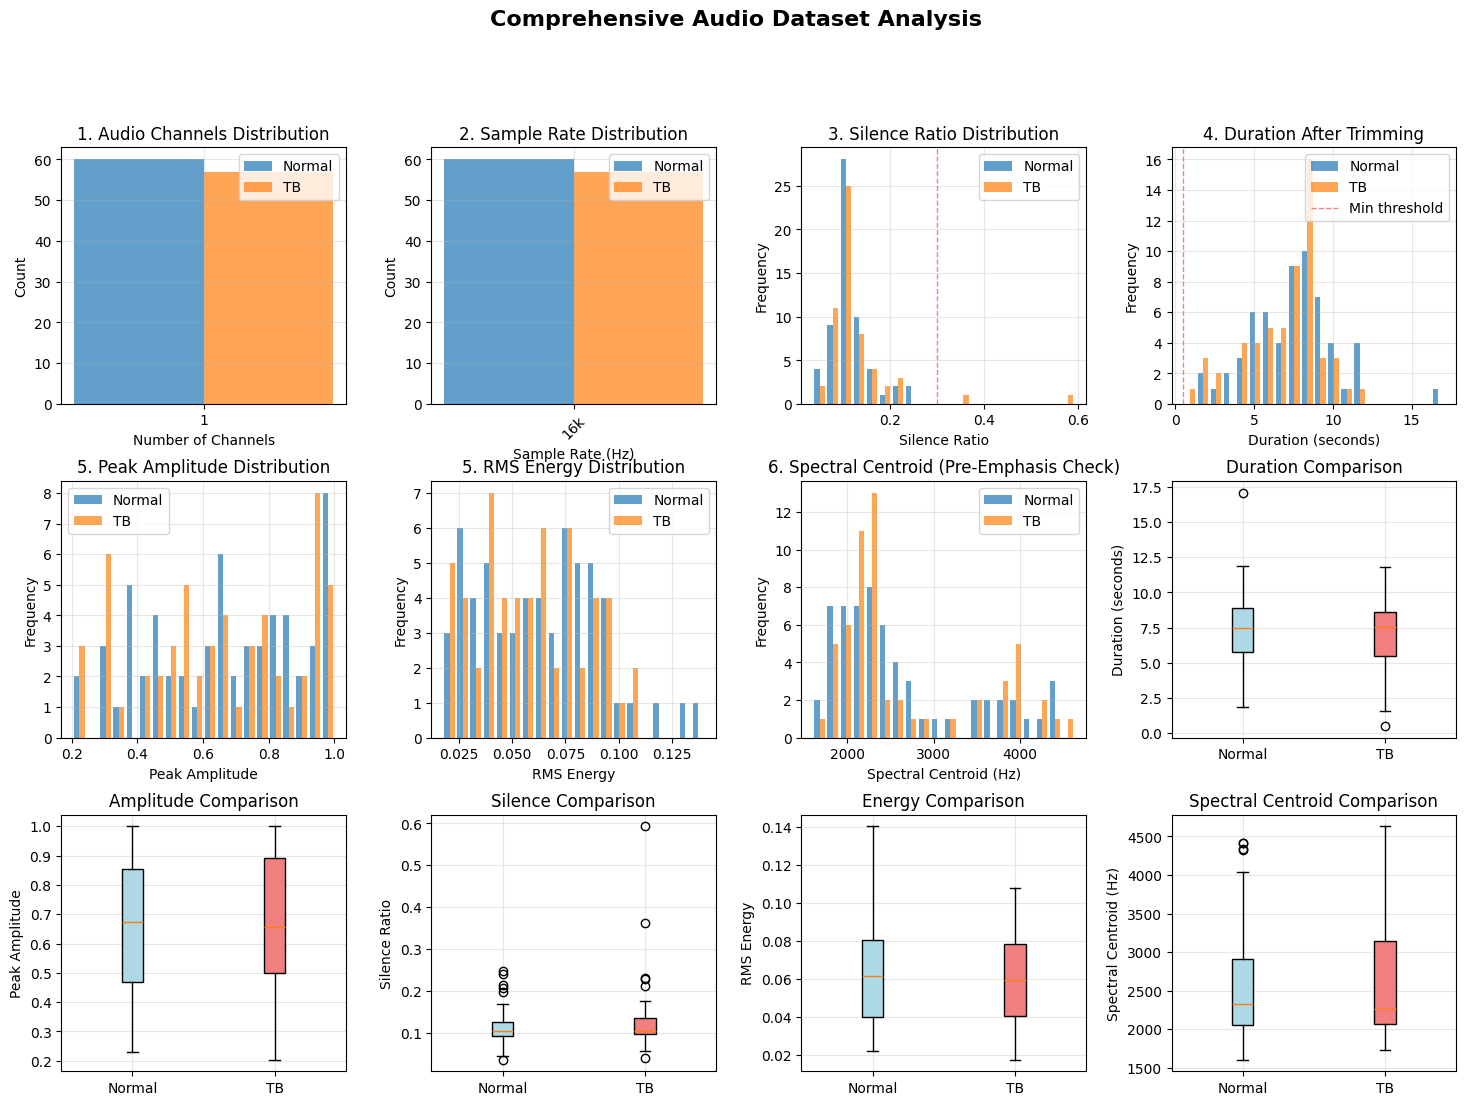

In [84]:
eda.plot_comprehensive_analysis(df_stats)

### Kesimpulan EDA dan Justifikasi Preprocessing

Berdasarkan analisis komprehensif di atas, strategi preprocessing dirancang untuk mengatasi 6 aspek kritis:

**1. Cek Kanal Audio (Channels)**
- Temuan EDA: Dataset memiliki variasi jumlah channel (mono/stereo)
- Solusi: Konversi semua audio menjadi Mono menggunakan `librosa.to_mono()`
- Justifikasi: MFCC diproses pada sinyal tunggal, stereo hanya menambah beban komputasi tanpa menambah informasi diagnostik batuk

**2. Cek Sample Rate (Frekuensi)**
- Temuan EDA: Sample rate bervariasi (8kHz, 16kHz, 44.1kHz, dll)
- Solusi: Resampling ke standar 16kHz menggunakan `librosa.resample()`
- Justifikasi: Konsistensi wajib untuk K-Means dan HMM, 16kHz cukup untuk suara manusia dan efisien secara komputasi

**3. Cek Keheningan (Silence Removal)**
- Temuan EDA: Rasio silence bervariasi 0-60% dari total durasi
- Solusi: Trimming dengan threshold top_db=20 dB menggunakan `librosa.effects.trim()`
- Justifikasi: Hening tidak mengandung informasi penyakit, jika tidak dibuang akan membuat Cluster 0 (hening) mendominasi dan menurunkan akurasi

**4. Cek Durasi Audio**
- Temuan EDA: Durasi setelah trim bervariasi, ada yang < 0.5 detik
- Solusi: Drop file dengan durasi < 0.5 detik, normalisasi sisanya ke 3 detik (padding/trimming)
- Justifikasi: Audio < 0.5 detik kemungkinan bukan batuk utuh atau hanya noise, tidak valid untuk analisis

**5. Cek Amplitudo (Volume Normalization)**
- Temuan EDA: Peak amplitude dan RMS energy sangat bervariasi antar file
- Solusi: Normalisasi amplitude ke rentang [-1, 1] dengan Peak Normalization
- Justifikasi: Perbedaan volume rekaman tidak boleh dianggap sebagai fitur pembeda, batuk pelan TB harus diperlakukan sama dengan batuk keras TB

**6. Pre-Emphasis Filter**
- Temuan EDA: Spectral centroid menunjukkan dominasi frekuensi rendah
- Solusi: Terapkan filter Pre-Emphasis dengan koefisien 0.97
- Justifikasi: Menyeimbangkan energi frekuensi tinggi yang lemah untuk ekstraksi MFCC yang lebih baik

**Bonus: Delta dan Delta-Delta MFCC**
- Menangkap dinamika temporal sinyal audio (laju perubahan dan percepatan)
- Penting untuk membedakan pola batuk TB vs normal
- Total 39 fitur per frame (13 MFCC + 13 Delta + 13 Delta²)

## Implementasi Preprocessing dengan 6 Validasi

Preprocessing dilakukan dengan 6 tahap validasi sesuai temuan EDA:

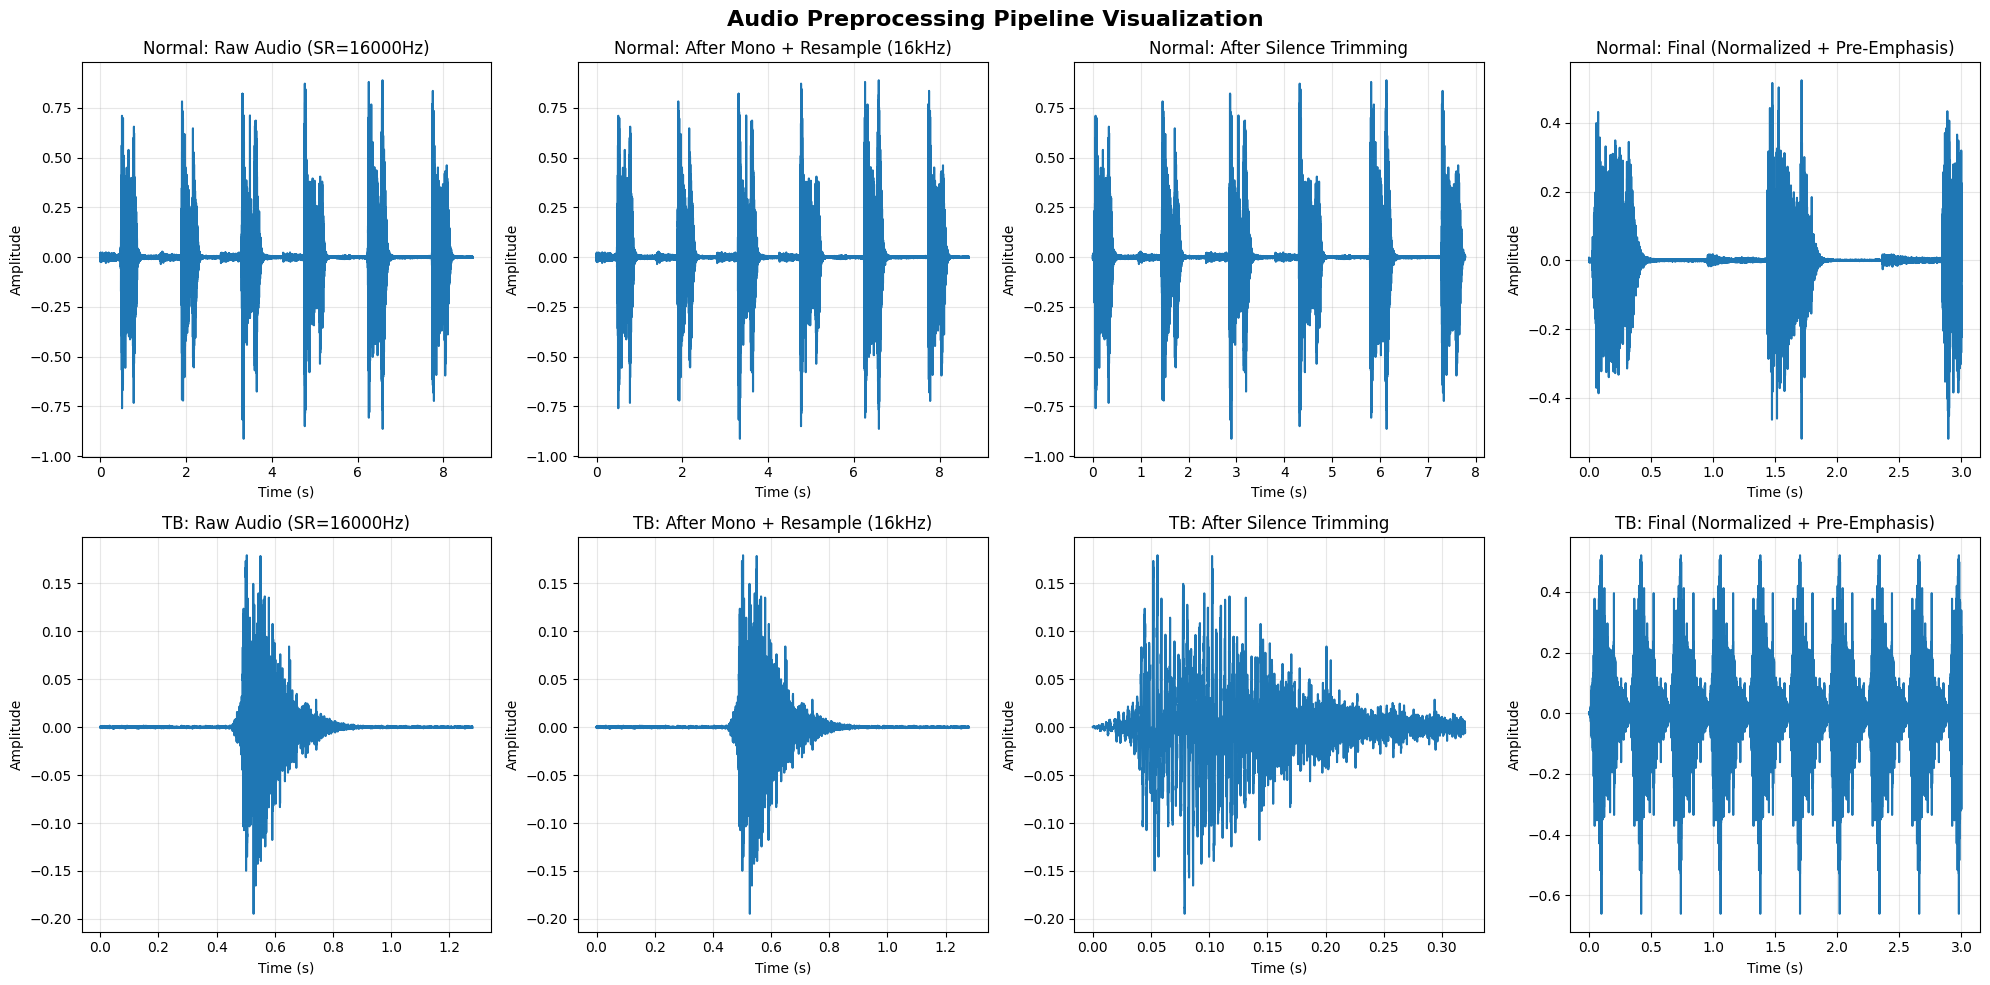

In [85]:
import librosa.display

sample_file_normal = os.path.join(TRAIN_NORMAL, os.listdir(TRAIN_NORMAL)[0])
sample_file_tb = os.path.join(TRAIN_TB, os.listdir(TRAIN_TB)[0])

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, (filepath, label) in enumerate([(sample_file_normal, 'Normal'), (sample_file_tb, 'TB')]):
    audio_raw, sr_raw = librosa.load(filepath, sr=None, mono=False)
    
    axes[idx, 0].plot(np.arange(len(audio_raw)) / sr_raw, audio_raw)
    axes[idx, 0].set_title(f'{label}: Raw Audio (SR={sr_raw}Hz)')
    axes[idx, 0].set_xlabel('Time (s)')
    axes[idx, 0].set_ylabel('Amplitude')
    axes[idx, 0].grid(True, alpha=0.3)
    
    preprocessor = AudioPreprocessor()
    
    audio_mono = preprocessor.check_and_convert_mono(audio_raw)
    audio_resampled = preprocessor.check_and_resample(audio_mono, sr_raw)
    axes[idx, 1].plot(np.arange(len(audio_resampled)) / preprocessor.sr, audio_resampled)
    axes[idx, 1].set_title(f'{label}: After Mono + Resample (16kHz)')
    axes[idx, 1].set_xlabel('Time (s)')
    axes[idx, 1].set_ylabel('Amplitude')
    axes[idx, 1].grid(True, alpha=0.3)
    
    audio_trimmed = preprocessor.check_and_trim_silence(audio_resampled)
    axes[idx, 2].plot(np.arange(len(audio_trimmed)) / preprocessor.sr, audio_trimmed)
    axes[idx, 2].set_title(f'{label}: After Silence Trimming')
    axes[idx, 2].set_xlabel('Time (s)')
    axes[idx, 2].set_ylabel('Amplitude')
    axes[idx, 2].grid(True, alpha=0.3)
    
    audio_normalized = preprocessor.check_and_normalize_amplitude(audio_trimmed)
    audio_padded = preprocessor.normalize_length(audio_normalized)
    audio_final = preprocessor.apply_pre_emphasis(audio_padded)
    axes[idx, 3].plot(np.arange(len(audio_final)) / preprocessor.sr, audio_final)
    axes[idx, 3].set_title(f'{label}: Final (Normalized + Pre-Emphasis)')
    axes[idx, 3].set_xlabel('Time (s)')
    axes[idx, 3].set_ylabel('Amplitude')
    axes[idx, 3].grid(True, alpha=0.3)

plt.suptitle('Audio Preprocessing Pipeline Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

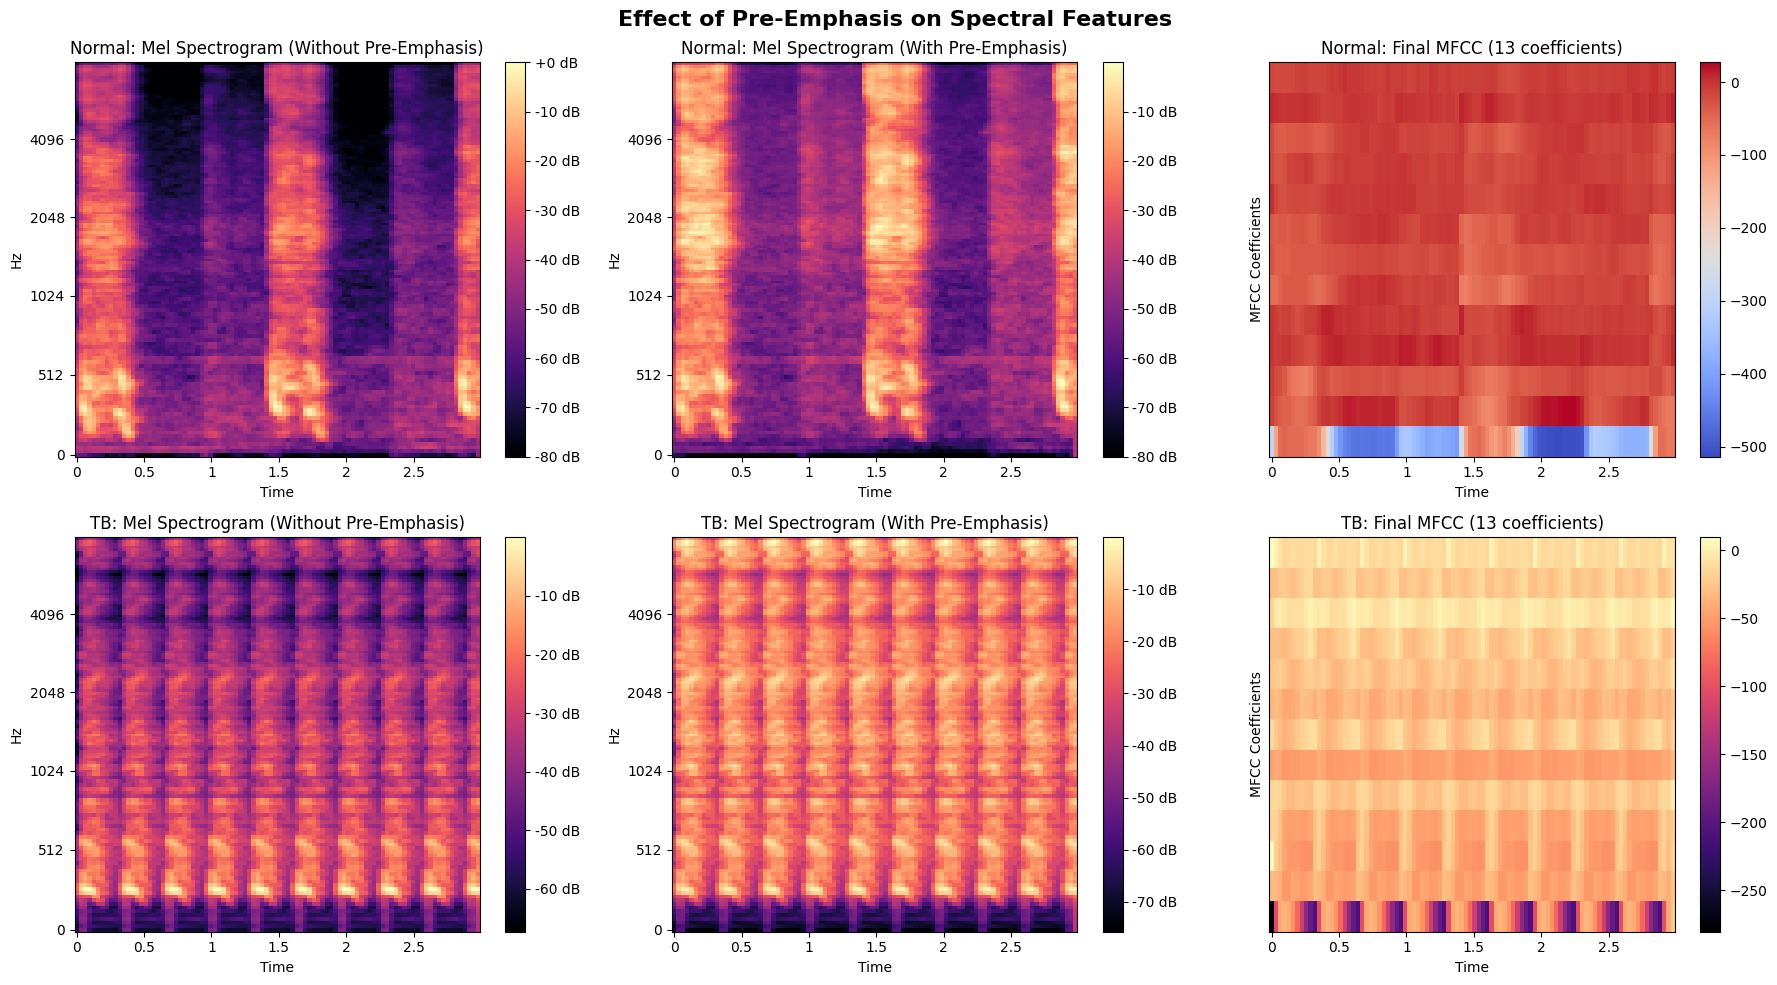

In [86]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (filepath, label) in enumerate([(sample_file_normal, 'Normal'), (sample_file_tb, 'TB')]):
    preprocessor = AudioPreprocessor()
    
    audio_raw, sr = librosa.load(filepath, sr=None, mono=False)
    audio_mono = preprocessor.check_and_convert_mono(audio_raw)
    audio_resampled = preprocessor.check_and_resample(audio_mono, sr)
    audio_trimmed = preprocessor.check_and_trim_silence(audio_resampled)
    audio_normalized = preprocessor.check_and_normalize_amplitude(audio_trimmed)
    audio_padded = preprocessor.normalize_length(audio_normalized)
    
    mfcc_without_preemph = librosa.feature.mfcc(y=audio_padded, sr=preprocessor.sr, n_mfcc=13)
    
    audio_preemph = preprocessor.apply_pre_emphasis(audio_padded)
    mfcc_with_preemph = librosa.feature.mfcc(y=audio_preemph, sr=preprocessor.sr, n_mfcc=13)
    
    spec_without = librosa.feature.melspectrogram(y=audio_padded, sr=preprocessor.sr)
    spec_with = librosa.feature.melspectrogram(y=audio_preemph, sr=preprocessor.sr)
    
    img1 = librosa.display.specshow(librosa.power_to_db(spec_without, ref=np.max), 
                                     y_axis='mel', x_axis='time', sr=preprocessor.sr, ax=axes[idx, 0])
    axes[idx, 0].set_title(f'{label}: Mel Spectrogram (Without Pre-Emphasis)')
    fig.colorbar(img1, ax=axes[idx, 0], format='%+2.0f dB')
    
    img2 = librosa.display.specshow(librosa.power_to_db(spec_with, ref=np.max), 
                                     y_axis='mel', x_axis='time', sr=preprocessor.sr, ax=axes[idx, 1])
    axes[idx, 1].set_title(f'{label}: Mel Spectrogram (With Pre-Emphasis)')
    fig.colorbar(img2, ax=axes[idx, 1], format='%+2.0f dB')
    
    img3 = librosa.display.specshow(mfcc_with_preemph, x_axis='time', sr=preprocessor.sr, ax=axes[idx, 2])
    axes[idx, 2].set_title(f'{label}: Final MFCC (13 coefficients)')
    axes[idx, 2].set_ylabel('MFCC Coefficients')
    fig.colorbar(img3, ax=axes[idx, 2])

plt.suptitle('Effect of Pre-Emphasis on Spectral Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualisasi Representasi Fitur MFCC dalam Ruang 3 Dimensi

Untuk memahami distribusi dan separabilitas fitur MFCC antara kelas TB dan Normal, dilakukan visualisasi dalam ruang tiga dimensi menggunakan Principal Component Analysis (PCA) untuk reduksi dimensi dari 39 fitur MFCC menjadi 3 komponen utama.

In [87]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go

# Ekstrak MFCC frames dengan sampling untuk reduksi clutter
all_mfcc_tb = []
all_mfcc_normal = []
preprocessor = AudioPreprocessor()

# Gunakan hanya 1 file per kelas untuk melihat perbedaan individu
n_files_per_class = 1

for folder, label in train_folders:
    files = [f for f in os.listdir(folder) if f.endswith('.wav')]
    
    # Ambil 1 file dari tengah dataset
    selected_files = files[len(files)//2:len(files)//2 + n_files_per_class]
    
    for filename in selected_files:
        filepath = os.path.join(folder, filename)
        try:
            mfcc = preprocessor.process_file(filepath)
            # Tidak perlu sampling, ambil semua frame untuk representasi lengkap
            if label == 'tb':
                all_mfcc_tb.append(mfcc)
            else:
                all_mfcc_normal.append(mfcc)
            print(f"Loaded: {label.upper()} - {filename}")
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            continue

all_mfcc_tb = np.vstack(all_mfcc_tb)
all_mfcc_normal = np.vstack(all_mfcc_normal)

# t-SNE reduksi dimensi ke 3D
print("\nApplying t-SNE dimensionality reduction (this may take a moment)...")
X = np.vstack([all_mfcc_tb, all_mfcc_normal])
tsne = TSNE(n_components=3, perplexity=30, random_state=42, max_iter=1000, verbose=1)
X_3d = tsne.fit_transform(X)
print("t-SNE completed!")

# Hitung center of gravity dan statistik
tb_indices = np.arange(len(all_mfcc_tb))
normal_indices = np.arange(len(all_mfcc_tb), len(X_3d))
center_tb = X_3d[tb_indices].mean(axis=0)
center_normal = X_3d[normal_indices].mean(axis=0)

# Hitung Euclidean distance antara centroid
centroid_distance = np.linalg.norm(center_tb - center_normal)

# Visualisasi 3D Interaktif dengan Plotly
fig = go.Figure()

# TB samples - gunakan opacity rendah untuk melihat overlap
fig.add_trace(go.Scatter3d(
    x=X_3d[tb_indices, 0],
    y=X_3d[tb_indices, 1],
    z=X_3d[tb_indices, 2],
    mode='markers',
    name='TB',
    marker=dict(
        size=4,
        color='#E74C3C',
        opacity=0.6,
        line=dict(width=0)
    ),
    hovertemplate='<b>TB Frame</b><br>t-SNE1: %{x:.2f}<br>t-SNE2: %{y:.2f}<br>t-SNE3: %{z:.2f}<extra></extra>'
))

# Normal samples
fig.add_trace(go.Scatter3d(
    x=X_3d[normal_indices, 0],
    y=X_3d[normal_indices, 1],
    z=X_3d[normal_indices, 2],
    mode='markers',
    name='Normal',
    marker=dict(
        size=4,
        color='#27AE60',
        opacity=0.6,
        line=dict(width=0)
    ),
    hovertemplate='<b>Normal Frame</b><br>t-SNE1: %{x:.2f}<br>t-SNE2: %{y:.2f}<br>t-SNE3: %{z:.2f}<extra></extra>'
))

# Center TB
fig.add_trace(go.Scatter3d(
    x=[center_tb[0]],
    y=[center_tb[1]],
    z=[center_tb[2]],
    mode='markers',
    name='Center TB',
    marker=dict(
        size=12,
        color='#C0392B',
        symbol='diamond',
        line=dict(color='white', width=3)
    ),
    hovertemplate='<b>Centroid TB</b><br>t-SNE1: %{x:.2f}<br>t-SNE2: %{y:.2f}<br>t-SNE3: %{z:.2f}<extra></extra>'
))

# Center Normal
fig.add_trace(go.Scatter3d(
    x=[center_normal[0]],
    y=[center_normal[1]],
    z=[center_normal[2]],
    mode='markers',
    name='Center Normal',
    marker=dict(
        size=12,
        color='#229954',
        symbol='diamond',
        line=dict(color='white', width=3)
    ),
    hovertemplate='<b>Centroid Normal</b><br>t-SNE1: %{x:.2f}<br>t-SNE2: %{y:.2f}<br>t-SNE3: %{z:.2f}<extra></extra>'
))

# Tambahkan garis connecting line antara centroid untuk menunjukkan separasi
fig.add_trace(go.Scatter3d(
    x=[center_tb[0], center_normal[0]],
    y=[center_tb[1], center_normal[1]],
    z=[center_tb[2], center_normal[2]],
    mode='lines',
    name=f'Separation (d={centroid_distance:.2f})',
    line=dict(color='gray', width=4, dash='dash'),
    hoverinfo='skip'
))

fig.update_layout(
    title=dict(
        text=f'Interactive 3D t-SNE: Single Sample Comparison (1 TB vs 1 Normal)<br><sub>Each point = 1 MFCC frame | Centroid Distance: {centroid_distance:.2f}</sub>',
        font=dict(size=14, family='Arial', color='black')
    ),
    scene=dict(
        xaxis_title='t-SNE Component 1',
        yaxis_title='t-SNE Component 2',
        zaxis_title='t-SNE Component 3',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        ),
        bgcolor='rgba(250, 250, 250, 1)'
    ),
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.95)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=11)
    ),
    width=1100,
    height=750,
    hovermode='closest'
)

fig.show()


print(f"3D t-SNE VISUALIZATION STATISTICS")

print(f"Algorithm: t-SNE (t-Distributed Stochastic Neighbor Embedding)")
print(f"Parameters: perplexity=30, max_iter=1000")
print(f"\nTotal Samples: {len(X_3d):,} frames")
print(f"  - TB: {len(tb_indices):,} frames")
print(f"  - Normal: {len(normal_indices):,} frames")
print(f"\nCentroid Positions:")
print(f"  - TB Center: [{center_tb[0]:.2f}, {center_tb[1]:.2f}, {center_tb[2]:.2f}]")
print(f"  - Normal Center: [{center_normal[0]:.2f}, {center_normal[1]:.2f}, {center_normal[2]:.2f}]")
print(f"  - Euclidean Distance: {centroid_distance:.2f}")


Loaded: TB - 01-399-0830_2.wav
Loaded: NORMAL - 01-399-0811_0.wav

Applying t-SNE dimensionality reduction (this may take a moment)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 188 samples in 0.004s...
[t-SNE] Computed neighbors for 188 samples in 0.033s...
[t-SNE] Computed conditional probabilities for sample 188 / 188
[t-SNE] Mean sigma: 33.254705
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.619999
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.619999
[t-SNE] KL divergence after 1000 iterations: 0.351737
t-SNE completed!
[t-SNE] KL divergence after 1000 iterations: 0.351737
t-SNE completed!


3D t-SNE VISUALIZATION STATISTICS
Algorithm: t-SNE (t-Distributed Stochastic Neighbor Embedding)
Parameters: perplexity=30, max_iter=1000

Total Samples: 188 frames
  - TB: 94 frames
  - Normal: 94 frames

Centroid Positions:
  - TB Center: [-3.86, -5.22, -14.85]
  - Normal Center: [3.79, 4.96, 16.13]
  - Euclidean Distance: 33.49


## Analisis Elbow Method untuk Menentukan Jumlah Cluster Optimal

Sebelum melakukan training, kita perlu menentukan jumlah cluster yang optimal untuk codebook menggunakan elbow method.

In [88]:
elbow_analyzer = ElbowMethodAnalyzer(min_clusters=10, max_clusters=150, step=10)
elbow_analyzer.analyze(train_folders)

Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Total MFCC frames untuk analisis: 9118

Menjalankan K-Means untuk 10 sampai 150 cluster...
Testing 10 clusters... Total MFCC frames untuk analisis: 9118

Menjalankan K-Means untuk 10 sampai 150 cluster...
Testing 10 clusters... Inertia: 38276500.00
Testing 20 clusters... Inertia: 38276500.00
Testing 20 clusters... Inertia: 30877406.00
Testing 30 clusters... Inertia: 30877406.00
Testing 30 clusters... Inertia: 27225164.00
Testing 40 clusters... Inertia: 27225164.00
Testing 40 clusters... Inertia: 25029070.00
Testing 50 clusters... Inertia: 25029070.00
Testing 50 clusters... Inertia: 23345566.00
Testing 60 clusters... Inertia: 23345566.00
Testing 60 clusters... Inertia: 22140538

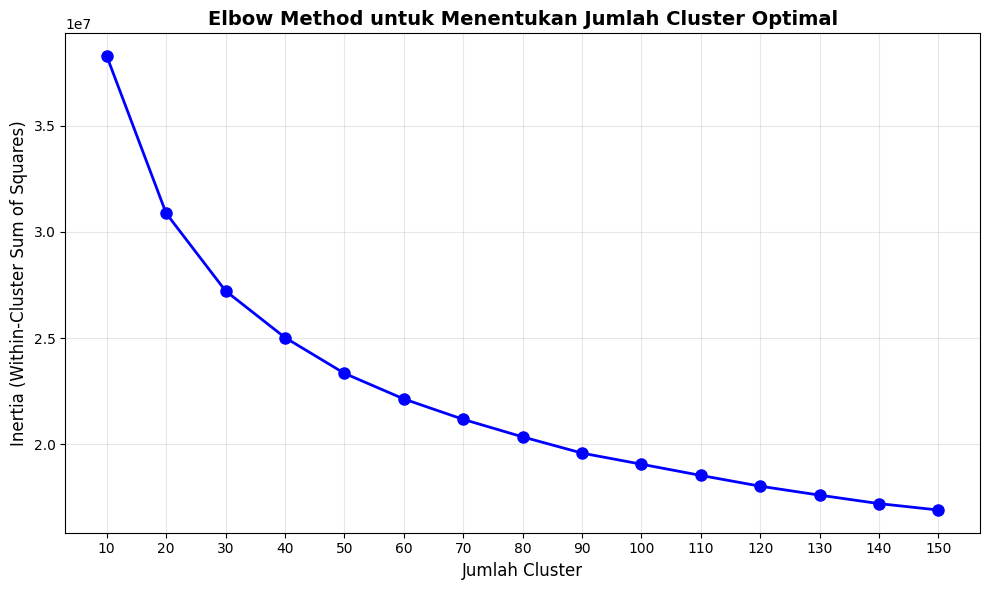

In [89]:
elbow_analyzer.plot_elbow()

In [90]:
# Dapatkan rekomendasi jumlah cluster optimal
optimal_clusters = elbow_analyzer.get_recommendation()

ELBOW POINT TERDETEKSI: 50 clusters
Inertia pada 50 clusters: 23345566.00
  codebook_gen = CodebookGenerator(n_clusters=50)


## Training dengan Jumlah Cluster Optimal

In [91]:
codebook_gen = CodebookGenerator(n_clusters=optimal_clusters)
codebook_gen.fit(train_folders)
codebook_gen.save('codebook.pkl')

Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Total MFCC frames: 9118
Total MFCC frames: 9118
Codebook trained dengan 50 clusters
Inertia: 23345564.00
Codebook trained dengan 50 clusters
Inertia: 23345564.00


In [92]:
quantizer = VectorQuantizer(codebook_gen)
data_preparer = DataPreparer(n_symbols=optimal_clusters)

# Prepare data in consistent DataFrame format
# HMM format: ['file_id', 'sequence', 'label']
# NB format: ['file_id', 'symbol_0', ..., 'symbol_N', 'label']
hmm_train_data = data_preparer.prepare_hmm_data(train_folders, quantizer)
hmm_test_data = data_preparer.prepare_hmm_data(test_folders, quantizer)

print("HMM DATA FORMAT:")

print(hmm_train_data[['file_id', 'label']].head(3))
print(f"\nSample sequence: {hmm_train_data.iloc[0]['sequence'][:15]}...")
print(f"Sequence length: {len(hmm_train_data.iloc[0]['sequence'])}")

Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
HMM tb: 47 files
HMM tb: 47 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 10 files
HMM DATA FORMAT:
             file_id label
0  01-399-0803_0.wav    tb
1  01-399-0803_1.wav    tb
2  01-399-0803_2.wav    tb

Sample sequence: [19, 27, 30, 30, 30, 32, 11, 1, 1, 1, 36, 36, 36, 36, 36]...
Sequence length: 94
HMM normal: 10 files
HMM DATA FORMAT:
             file_id label
0  01-399-0803_0.wav    tb
1  01-399-0803_1.wav    tb
2  01-399-0803_2.wav    tb

Sample sequence: [19, 27, 30, 30, 30, 32, 11, 1, 1, 1, 36, 36, 36, 36, 36]...
Sequence length: 94


In [93]:
nb_train_df = data_preparer.prepare_nb_data(train_folders, quantizer)
nb_test_df = data_preparer.prepare_nb_data(test_folders, quantizer)

print("NAIVE BAYES DATA FORMAT:")
print(nb_train_df[['file_id', 'label', 'symbol_0', 'symbol_1', 'symbol_2']].head(3))
print(f"\nTotal frequency features: {len([col for col in nb_train_df.columns if col.startswith('symbol_')])}")
print("DATA CONSISTENCY CHECK:")
print(f"Same file IDs: {hmm_train_data['file_id'].equals(nb_train_df['file_id'])}")
print(f"Same labels: {hmm_train_data['label'].equals(nb_train_df['label'])}")

Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
NB tb: 47 files
NB tb: 47 files
NB normal: 50 files
NB tb: 10 files
NB normal: 50 files
NB tb: 10 files
NB normal: 10 files
NAIVE BAYES DATA FORMAT:
             file_id label  symbol_0  symbol_1  symbol_2
0  01-399-0803_0.wav    tb         0        11         1
1  01-399-0803_1.wav    tb         0         9         4
2  01-399-0803_2.wav    tb         0         7         0

Total frequency features: 50
DATA CONSISTENCY CHECK:
Same file IDs: True
Same labels: True
NB normal: 10 files
NAIVE BAYES DATA FORMAT:
             file_id label  symbol_0  symbol_1  symbol_2
0  01-399-0803_0.wav    tb         0        11         1
1  01-399-0803_1.wav    tb         0         9         4


In [94]:
hmm_classifier = HMMClassifier(n_components=5, n_iter=100)
hmm_classifier.train(hmm_train_data)

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
HMM normal trained with 50 sequences


In [95]:
nb_classifier = NaiveBayesClassifier()
nb_classifier.train(nb_train_df)

Naive Bayes trained


In [96]:
# Evaluate HMM
hmm_predictions = hmm_classifier.predict_batch(hmm_test_data)
hmm_true_labels = hmm_test_data['label'].values
results_hmm = ModelEvaluator.evaluate(hmm_true_labels, hmm_predictions, "HMM")

print("HMM DATA STRUCTURE (First 3 rows):")

print(hmm_test_data[['file_id', 'label']].head(3))
print(f"\nSample sequence for first file:")
print(f"  File: {hmm_test_data.iloc[0]['file_id']}")
print(f"  Sequence length: {len(hmm_test_data.iloc[0]['sequence'])}")
print(f"  First 20 symbols: {hmm_test_data.iloc[0]['sequence'][:20]}")
print(f"  Label: {hmm_test_data.iloc[0]['label']}")


HMM
Confusion Matrix:
              Normal    TB
Normal          10      0
TB              10      0
Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
HMM DATA STRUCTURE (First 3 rows):
             file_id label
0  01-399-0844_0.wav    tb
1  01-399-0844_1.wav    tb
2  01-399-0844_2.wav    tb

Sample sequence for first file:
  File: 01-399-0844_0.wav
  Sequence length: 94
  First 20 symbols: [31, 27, 30, 2, 32, 11, 11, 11, 11, 7, 7, 36, 39, 49, 41, 19, 42, 16, 16, 17]
  Label: tb


In [97]:
# Evaluate Naive Bayes
nb_predictions = nb_classifier.predict(nb_test_df)
nb_true_labels = nb_test_df['label'].values
results_nb = ModelEvaluator.evaluate(nb_true_labels, nb_predictions, "Naive Bayes")

print("NAIVE BAYES DATA STRUCTURE (First 3 rows, selected columns):")

display_cols = ['file_id', 'label', 'symbol_0', 'symbol_1', 'symbol_2']
print(nb_test_df[display_cols].head(3))
print(f"\nTotal features per file: {len([col for col in nb_test_df.columns if col.startswith('symbol_')])}")

print("DATA ALIGNMENT VERIFICATION:")

print(f"HMM files: {len(hmm_test_data)}")
print(f"NB files: {len(nb_test_df)}")
print(f"File IDs match: {hmm_test_data['file_id'].equals(nb_test_df['file_id'])}")
if hmm_test_data['file_id'].equals(nb_test_df['file_id']):
    print("✓ Both datasets have the same files in the same order")
else:
    print("⚠ Warning: File ordering differs between HMM and NB datasets")


Naive Bayes
Confusion Matrix:
              Normal    TB
Normal          10      0
TB               2      8
Accuracy:  0.9000
Precision: 1.0000
Recall:    0.8000
F1-Score:  0.8889
NAIVE BAYES DATA STRUCTURE (First 3 rows, selected columns):
             file_id label  symbol_0  symbol_1  symbol_2
0  01-399-0844_0.wav    tb         3         0         1
1  01-399-0844_1.wav    tb         7         3         3
2  01-399-0844_2.wav    tb         7         3         0

Total features per file: 50
DATA ALIGNMENT VERIFICATION:
HMM files: 20
NB files: 20
File IDs match: True
✓ Both datasets have the same files in the same order


In [98]:
ModelEvaluator.compare_models(results_hmm, results_nb)


Comparison:
Metric                   HMM  Naive Bayes
Accuracy             0.5000      0.9000
Precision            0.0000      1.0000
Recall               0.0000      0.8000
F1-Score             0.0000      0.8889

Interpretation:
Naive Bayes performs better  - frequency distribution is more informative


## Analisis Distribusi Codebook per Kelas

Analisis ini bertujuan untuk mengidentifikasi simbol codebook mana yang paling sering muncul pada kelas TB dan Normal, sehingga dapat memberikan interpretasi tentang karakteristik akustik yang membedakan kedua kelas.


Total codebook symbols: 50
Total TB files: 47
Total Normal files: 50
Total TB frames: 4,418
Total Normal frames: 4,700
TOP 10 MOST FREQUENT CODEBOOK SYMBOLS IN TB CLASS:
Rank   Symbol       Count           Avg per File
1      13           193             4.11
2      38           185             3.94
3      16           181             3.85
4      20           179             3.81
5      11           171             3.64
6      17           161             3.43
7      30           161             3.43
8      43           144             3.06
9      36           122             2.60
10     33           119             2.53
TOP 10 MOST FREQUENT CODEBOOK SYMBOLS IN NORMAL CLASS:
Rank   Symbol       Count           Avg per File
1      20           273             5.46
2      16           241             4.82
3      19           229             4.58
4      13           179             3.58
5      17           175             3.50
6      5            171             3.42
7      4            

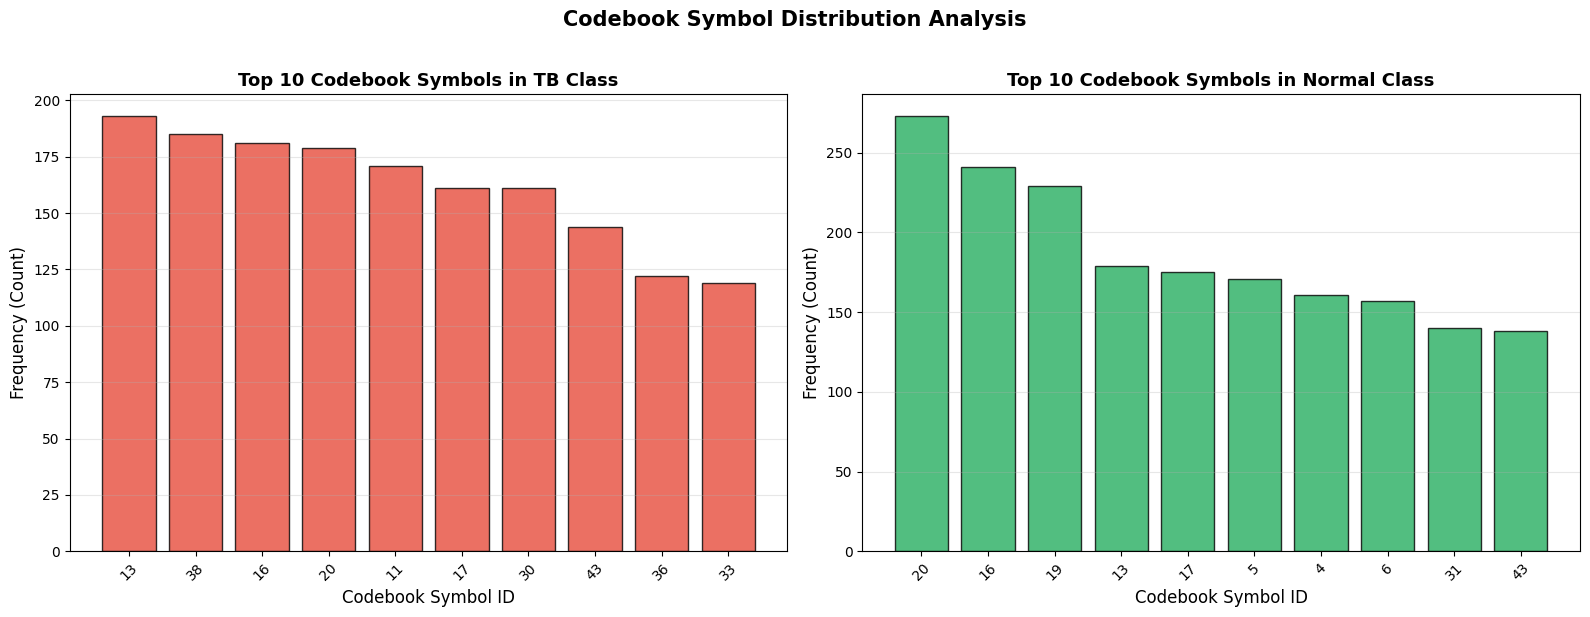

INTERPRETATION:
- Symbols yang unique ke TB menangkap karakteristik akustik spesifik batuk TB
- Symbols yang unique ke Normal menangkap karakteristik batuk sehat
- Shared symbols merepresentasikan fitur umum yang muncul di kedua kelas
- Model Naive Bayes menggunakan perbedaan distribusi ini untuk klasifikasi


In [99]:
# Analisis Distribusi Codebook: Top Symbols per Class

# Hitung total frekuensi setiap symbol untuk setiap kelas
symbol_cols = [col for col in nb_train_df.columns if col.startswith('symbol_')]
n_symbols = len(symbol_cols)

# Agregasi frekuensi per kelas (raw count)
tb_freq = nb_train_df[nb_train_df['label'] == 'tb'][symbol_cols].sum()
normal_freq = nb_train_df[nb_train_df['label'] == 'normal'][symbol_cols].sum()

# Top 10 symbols untuk setiap kelas
top_n = 10
tb_top = tb_freq.nlargest(top_n)
normal_top = normal_freq.nlargest(top_n)

# Total frames untuk statistik
tb_total_frames = tb_freq.sum()
normal_total_frames = normal_freq.sum()

print(f"\nTotal codebook symbols: {n_symbols}")
print(f"Total TB files: {len(nb_train_df[nb_train_df['label'] == 'tb'])}")
print(f"Total Normal files: {len(nb_train_df[nb_train_df['label'] == 'normal'])}")
print(f"Total TB frames: {int(tb_total_frames):,}")
print(f"Total Normal frames: {int(normal_total_frames):,}")

print("TOP 10 MOST FREQUENT CODEBOOK SYMBOLS IN TB CLASS:")

print(f"{'Rank':<6} {'Symbol':<12} {'Count':<15} {'Avg per File'}")

for rank, (symbol, count) in enumerate(tb_top.items(), 1):
    symbol_id = int(symbol.split('_')[1])
    avg_per_file = count / len(nb_train_df[nb_train_df['label'] == 'tb'])
    print(f"{rank:<6} {symbol_id:<12} {int(count):<15,} {avg_per_file:.2f}")

print("TOP 10 MOST FREQUENT CODEBOOK SYMBOLS IN NORMAL CLASS:")

print(f"{'Rank':<6} {'Symbol':<12} {'Count':<15} {'Avg per File'}")

for rank, (symbol, count) in enumerate(normal_top.items(), 1):
    symbol_id = int(symbol.split('_')[1])
    avg_per_file = count / len(nb_train_df[nb_train_df['label'] == 'normal'])
    print(f"{rank:<6} {symbol_id:<12} {int(count):<15,} {avg_per_file:.2f}")

# Identifikasi symbols yang distinctive (hanya muncul di top salah satu kelas)
tb_top_ids = set([int(s.split('_')[1]) for s in tb_top.index])
normal_top_ids = set([int(s.split('_')[1]) for s in normal_top.index])

tb_unique = tb_top_ids - normal_top_ids
normal_unique = normal_top_ids - tb_top_ids
shared = tb_top_ids & normal_top_ids

print("DISCRIMINATIVE SYMBOLS ANALYSIS:")

print(f"\nSymbols unique to TB top-10: {sorted(tb_unique)}")
print(f"Symbols unique to Normal top-10: {sorted(normal_unique)}")
print(f"Shared symbols (appear in both top-10): {sorted(shared)}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot TB
tb_top_ids_sorted = [int(s.split('_')[1]) for s in tb_top.index]
axes[0].bar(range(top_n), tb_top.values, color='#E74C3C', alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(top_n))
axes[0].set_xticklabels(tb_top_ids_sorted, rotation=45)
axes[0].set_xlabel('Codebook Symbol ID', fontsize=12)
axes[0].set_ylabel('Frequency (Count)', fontsize=12)
axes[0].set_title('Top 10 Codebook Symbols in TB Class', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Plot Normal
normal_top_ids_sorted = [int(s.split('_')[1]) for s in normal_top.index]
axes[1].bar(range(top_n), normal_top.values, color='#27AE60', alpha=0.8, edgecolor='black')
axes[1].set_xticks(range(top_n))
axes[1].set_xticklabels(normal_top_ids_sorted, rotation=45)
axes[1].set_xlabel('Codebook Symbol ID', fontsize=12)
axes[1].set_ylabel('Frequency (Count)', fontsize=12)
axes[1].set_title('Top 10 Codebook Symbols in Normal Class', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.suptitle('Codebook Symbol Distribution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("INTERPRETATION:")

print("- Symbols yang unique ke TB menangkap karakteristik akustik spesifik batuk TB")
print("- Symbols yang unique ke Normal menangkap karakteristik batuk sehat")
print("- Shared symbols merepresentasikan fitur umum yang muncul di kedua kelas")
print("- Model Naive Bayes menggunakan perbedaan distribusi ini untuk klasifikasi")


## Skenario Pengujian Model

Untuk mengevaluasi performa model secara komprehensif, dilakukan tiga skenario pengujian yang dirancang untuk membandingkan karakteristik model berbasis frekuensi (Naive Bayes) dan model berbasis sekuensial (HMM) dalam berbagai kondisi.

### Skenario 1: Pengujian dengan Jumlah Cluster Bervariasi

Skenario ini menguji pengaruh jumlah cluster (ukuran codebook) terhadap akurasi kedua model. Hipotesis: HMM lebih robust terhadap perubahan ukuran codebook karena memanfaatkan informasi sekuensial, sementara Naive Bayes sangat bergantung pada granularitas representasi frekuensi.

Testing with 32 clusters...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Total MFCC frames: 9118
Total MFCC frames: 9118
Codebook trained dengan 32 clusters
Inertia: 26751890.00
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Codebook trained dengan 32 clusters
Inertia: 26751890.00
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
HMM tb: 47 files
HMM tb: 47 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 50 files
HMM tb: 10 files
HMM nor

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 10 files
HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
Naive Bayes trained
HMM Accuracy: 0.5000 | NB Accuracy: 0.7500

Testing with 64 clusters...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Total MFCC frames: 9118
Total MFCC frames: 9118
Codebook trained dengan 64 clusters
Inertia: 21760374.00
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Codebook trained dengan 64 clusters
Inertia: 21760374.00
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav -

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 10 files
HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
Naive Bayes trained
HMM Accuracy: 0.5000 | NB Accuracy: 0.8500

Testing with 128 clusters...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Total MFCC frames: 9118
Total MFCC frames: 9118
Codebook trained dengan 128 clusters
Inertia: 17678640.00
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Codebook trained dengan 128 clusters
Inertia: 17678640.00
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wa

...

NB normal: 10 files
HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
Naive Bayes trained
HMM Accuracy: 0.5000 | NB Accuracy: 0.8500

Testing with 256 clusters...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Total MFCC frames: 9118
Total MFCC frames: 9118
Codebook trained dengan 256 clusters
Inertia: 14190547.00
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Codebook trained dengan 256 clusters
Inertia: 14190547.00
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wa

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


NB tb: 10 files
NB normal: 10 files


MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
Naive Bayes trained
HMM Accuracy: 0.5000 | NB Accuracy: 0.7500



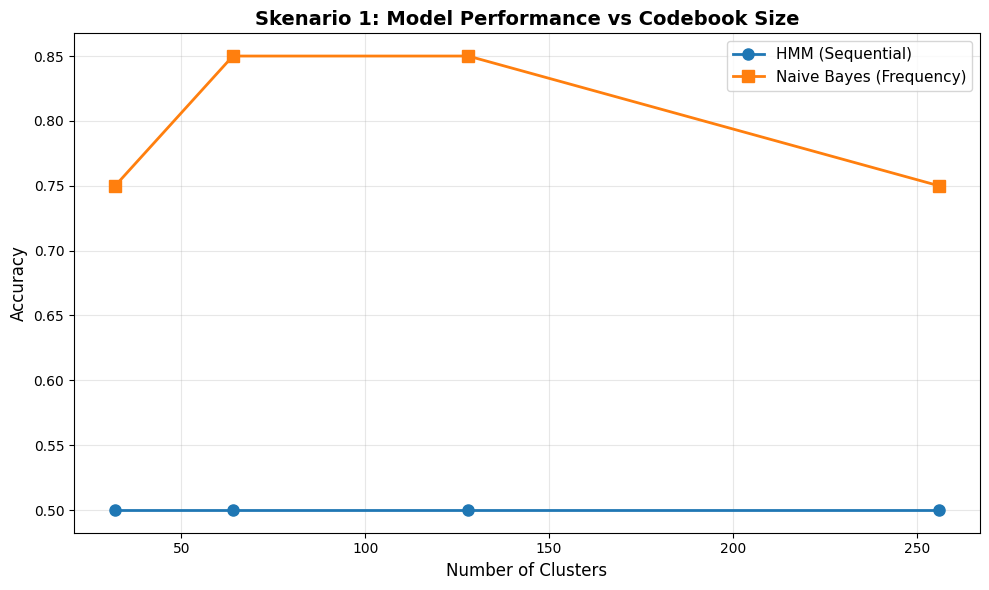

In [100]:
cluster_sizes = [32, 64, 128, 256]
results_scenario1 = {'clusters': [], 'hmm_accuracy': [], 'nb_accuracy': []}

for n_clusters in cluster_sizes:
    print(f"Testing with {n_clusters} clusters...")
    
    codebook = CodebookGenerator(n_clusters=n_clusters)
    codebook.fit(train_folders)
    
    quantizer = VectorQuantizer(codebook)
    data_prep = DataPreparer(n_symbols=n_clusters)
    
    hmm_train = data_prep.prepare_hmm_data(train_folders, quantizer)
    hmm_test = data_prep.prepare_hmm_data(test_folders, quantizer)
    nb_train = data_prep.prepare_nb_data(train_folders, quantizer)
    nb_test = data_prep.prepare_nb_data(test_folders, quantizer)
    
    hmm_clf = HMMClassifier(n_components=5, n_iter=100)
    hmm_clf.train(hmm_train)
    
    nb_clf = NaiveBayesClassifier()
    nb_clf.train(nb_train)
    
    # Predict using DataFrame format
    hmm_pred = hmm_clf.predict_batch(hmm_test)
    nb_pred = nb_clf.predict(nb_test)
    
    hmm_acc = accuracy_score(hmm_test['label'].values, hmm_pred)
    nb_acc = accuracy_score(nb_test['label'].values, nb_pred)
    
    results_scenario1['clusters'].append(n_clusters)
    results_scenario1['hmm_accuracy'].append(hmm_acc)
    results_scenario1['nb_accuracy'].append(nb_acc)
    
    print(f"HMM Accuracy: {hmm_acc:.4f} | NB Accuracy: {nb_acc:.4f}\n")

plt.figure(figsize=(10, 6))
plt.plot(results_scenario1['clusters'], results_scenario1['hmm_accuracy'], 
         marker='o', linewidth=2, markersize=8, label='HMM (Sequential)')
plt.plot(results_scenario1['clusters'], results_scenario1['nb_accuracy'], 
         marker='s', linewidth=2, markersize=8, label='Naive Bayes (Frequency)')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Skenario 1: Model Performance vs Codebook Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Skenario 2: Pengujian dengan Variasi Ukuran Training Data

Skenario ini mengevaluasi pengaruh jumlah data training terhadap performa kedua model dengan melakukan sampling bertahap dari 25%, 50%, 75%, hingga 100% data training. Hipotesis: HMM memerlukan lebih banyak data untuk memodelkan pola transisi temporal yang kompleks, sementara Naive Bayes dapat bekerja efektif dengan data lebih sedikit karena hanya perlu membangun distribusi frekuensi.

Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Total MFCC frames: 9118
Total MFCC frames: 9118
Codebook trained dengan 50 clusters
Inertia: 23345564.00
HMM tb: 10 files
Codebook trained dengan 50 clusters
Inertia: 23345564.00
HMM tb: 10 files
HMM normal: 10 files
NB tb: 10 files
HMM normal: 10 files
NB tb: 10 files
NB normal: 10 files
SKENARIO 2: TRAINING DATA SIZE VARIATION

Testing with 25% of training data...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
NB normal: 10 files
SKENARIO 2: TRAINING DATA SIZE VARIATION

Testing with 25% of training data...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - A

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 50 files
  Train samples: 23 files (TB: 11, Normal: 12)
HMM tb trained with 11 sequences
HMM normal trained with 12 sequences
Naive Bayes trained
  HMM - Acc: 0.5000, Prec: 0.0000, Rec: 0.0000, F1: 0.0000
  NB  - Acc: 0.6000, Prec: 0.5714, Rec: 0.8000, F1: 0.6667

Testing with 50% of training data...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
HMM tb: 47 files
HMM tb: 47 files
HMM normal: 50 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
HMM normal: 50 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 50 files
  Train samples: 48 files (TB: 23, Normal: 25)
HMM tb trained with 23 sequences
HMM normal trained with 25 sequences
Naive Bayes trained
  HMM - Acc: 0.5000, Prec: 0.0000, Rec: 0.0000, F1: 0.0000
  NB  - Acc: 0.8500, Prec: 0.8889, Rec: 0.8000, F1: 0.8421

Testing with 75% of training data...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
HMM tb: 47 files
HMM tb: 47 files
HMM normal: 50 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
HMM normal: 50 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 50 files
  Train samples: 72 files (TB: 35, Normal: 37)
HMM tb trained with 35 sequences
HMM normal trained with 37 sequences
Naive Bayes trained
  HMM - Acc: 0.5000, Prec: 0.0000, Rec: 0.0000, F1: 0.0000
  NB  - Acc: 0.7000, Prec: 0.8333, Rec: 0.5000, F1: 0.6250

Testing with 100% of training data...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
  HMM - Acc: 0.5000, Prec: 0.0000, Rec: 0.0000, F1: 0.0000
  NB  - Acc: 0.7000, Prec: 0.8333, Rec: 0.5000, F1: 0.6250

Testing with 100% of training data...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
HMM tb: 47 files
HMM tb: 47 files
HMM normal: 50 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
HMM normal: 50 files
Error: 01-39

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 50 files
  Train samples: 97 files (TB: 47, Normal: 50)
HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
Naive Bayes trained
  HMM - Acc: 0.5000, Prec: 0.0000, Rec: 0.0000, F1: 0.0000
  NB  - Acc: 0.9000, Prec: 1.0000, Rec: 0.8000, F1: 0.8889
  HMM - Acc: 0.5000, Prec: 0.0000, Rec: 0.0000, F1: 0.0000
  NB  - Acc: 0.9000, Prec: 1.0000, Rec: 0.8000, F1: 0.8889


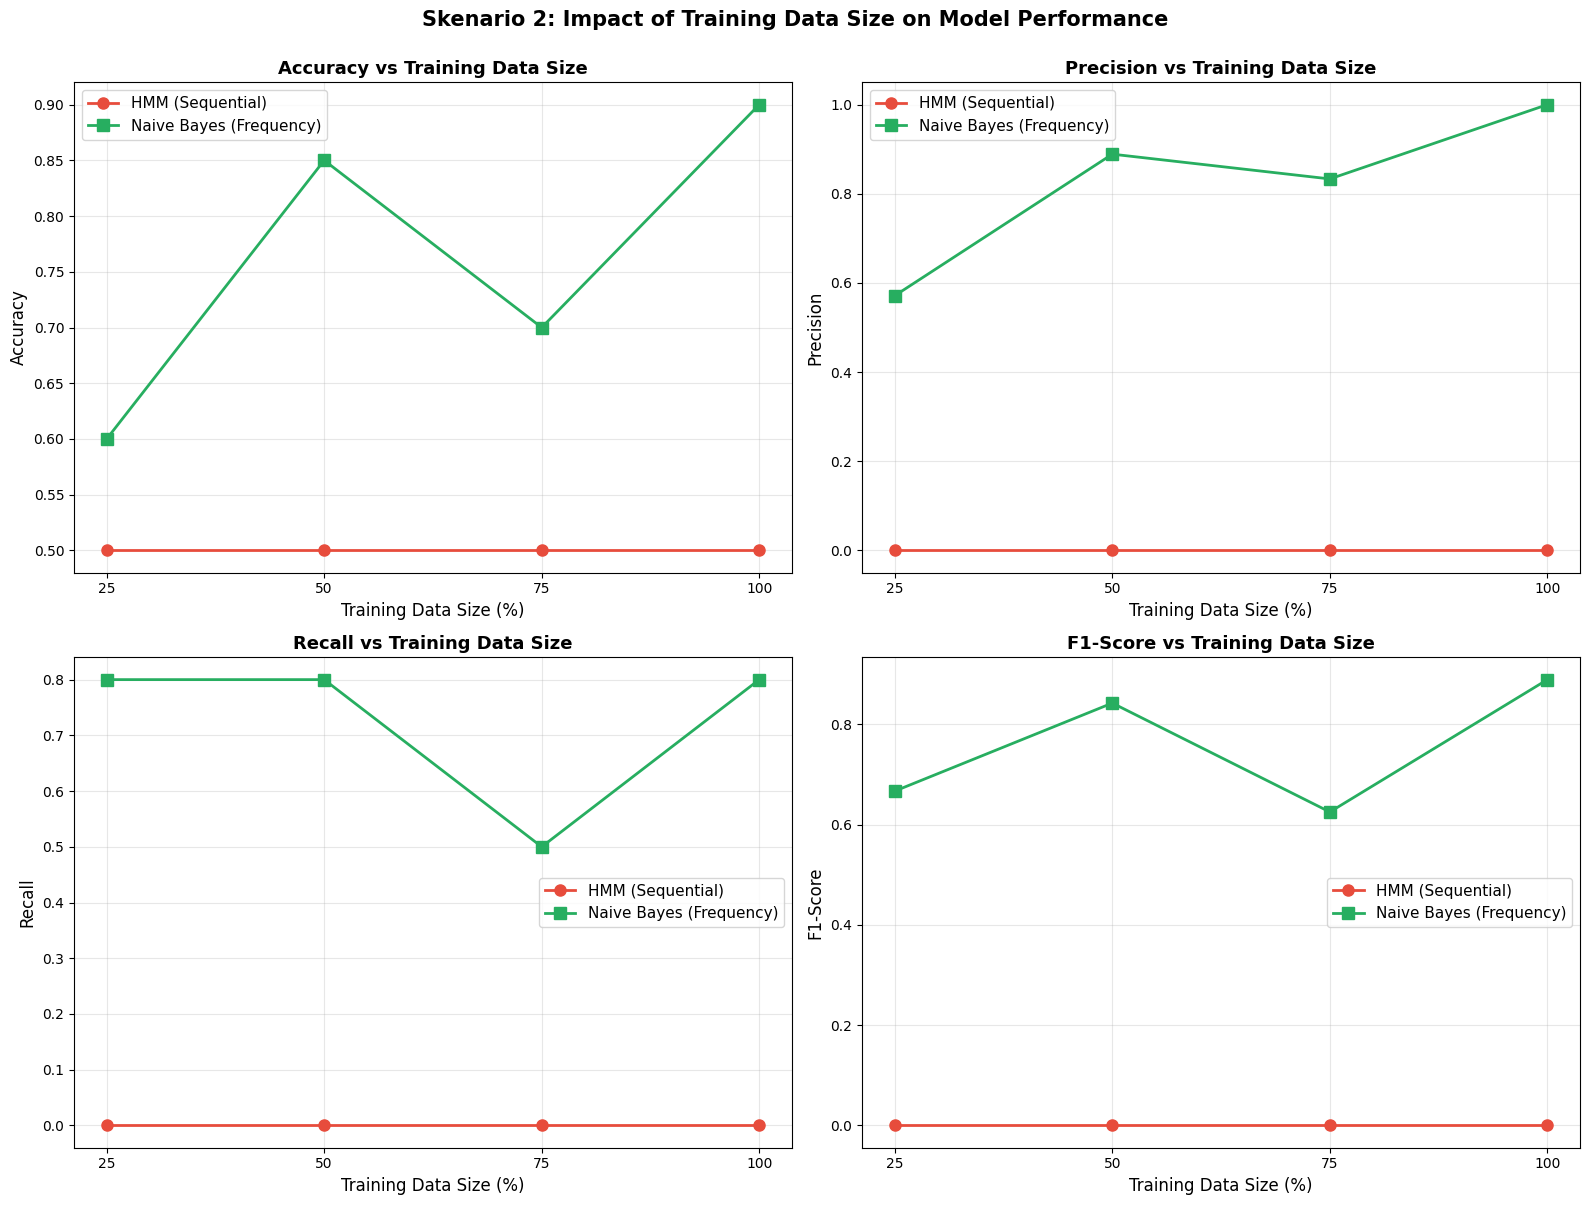

INTERPRETATION:
- Model dengan learning curve lebih curam = butuh lebih banyak data
- Model yang plateau cepat = efisien dengan data terbatas
- Gap performa kecil di data kecil = model sederhana lebih robust
- Gap performa membesar di data banyak = model kompleks lebih ekspresif


In [104]:
# Variasi persentase training data
train_sizes = [0.25, 0.50, 0.75, 1.0]
results_scenario2 = {
    'train_size': [], 
    'hmm_accuracy': [], 'nb_accuracy': [],
    'hmm_precision': [], 'nb_precision': [],
    'hmm_recall': [], 'nb_recall': [],
    'hmm_f1': [], 'nb_f1': []
}

# Gunakan codebook yang sudah optimal
codebook_base = CodebookGenerator(n_clusters=optimal_clusters)
codebook_base.fit(train_folders)
quantizer_base = VectorQuantizer(codebook_base)
data_prep_base = DataPreparer(n_symbols=optimal_clusters)

# Prepare full test data (tetap sama untuk semua iterasi)
hmm_test_full = data_prep_base.prepare_hmm_data(test_folders, quantizer_base)
nb_test_full = data_prep_base.prepare_nb_data(test_folders, quantizer_base)

print("SKENARIO 2: TRAINING DATA SIZE VARIATION")

for train_size in train_sizes:
    print(f"\nTesting with {int(train_size*100)}% of training data...")
    
    # Prepare data dengan sampling
    hmm_train_full = data_prep_base.prepare_hmm_data(train_folders, quantizer_base)
    nb_train_full = data_prep_base.prepare_nb_data(train_folders, quantizer_base)
    
    # Sampling stratified (maintain class distribution)
    tb_train = hmm_train_full[hmm_train_full['label'] == 'tb']
    normal_train = hmm_train_full[hmm_train_full['label'] == 'normal']
    
    n_tb_sample = int(len(tb_train) * train_size)
    n_normal_sample = int(len(normal_train) * train_size)
    
    tb_sampled = tb_train.sample(n=n_tb_sample, random_state=42)
    normal_sampled = normal_train.sample(n=n_normal_sample, random_state=42)
    
    hmm_train_sampled = pd.concat([tb_sampled, normal_sampled], ignore_index=True)
    
    # Sample NB data dengan file_id yang sama
    sampled_file_ids = set(hmm_train_sampled['file_id'])
    nb_train_sampled = nb_train_full[nb_train_full['file_id'].isin(sampled_file_ids)]
    
    print(f"  Train samples: {len(hmm_train_sampled)} files (TB: {n_tb_sample}, Normal: {n_normal_sample})")
    
    # Train HMM
    hmm_clf = HMMClassifier(n_components=5, n_iter=100)
    hmm_clf.train(hmm_train_sampled)
    
    # Train NB
    nb_clf = NaiveBayesClassifier()
    nb_clf.train(nb_train_sampled)
    
    # Predict
    hmm_pred = hmm_clf.predict_batch(hmm_test_full)
    nb_pred = nb_clf.predict(nb_test_full)
    
    hmm_true = hmm_test_full['label'].values
    nb_true = nb_test_full['label'].values
    
    # Evaluate
    hmm_acc = accuracy_score(hmm_true, hmm_pred)
    nb_acc = accuracy_score(nb_true, nb_pred)
    
    hmm_prec = precision_score(hmm_true, hmm_pred, pos_label='tb', zero_division=0)
    nb_prec = precision_score(nb_true, nb_pred, pos_label='tb', zero_division=0)
    
    hmm_rec = recall_score(hmm_true, hmm_pred, pos_label='tb', zero_division=0)
    nb_rec = recall_score(nb_true, nb_pred, pos_label='tb', zero_division=0)
    
    hmm_f1 = f1_score(hmm_true, hmm_pred, pos_label='tb', zero_division=0)
    nb_f1 = f1_score(nb_true, nb_pred, pos_label='tb', zero_division=0)
    
    # Store results
    results_scenario2['train_size'].append(int(train_size * 100))
    results_scenario2['hmm_accuracy'].append(hmm_acc)
    results_scenario2['nb_accuracy'].append(nb_acc)
    results_scenario2['hmm_precision'].append(hmm_prec)
    results_scenario2['nb_precision'].append(nb_prec)
    results_scenario2['hmm_recall'].append(hmm_rec)
    results_scenario2['nb_recall'].append(nb_rec)
    results_scenario2['hmm_f1'].append(hmm_f1)
    results_scenario2['nb_f1'].append(nb_f1)
    
    print(f"  HMM - Acc: {hmm_acc:.4f}, Prec: {hmm_prec:.4f}, Rec: {hmm_rec:.4f}, F1: {hmm_f1:.4f}")
    print(f"  NB  - Acc: {nb_acc:.4f}, Prec: {nb_prec:.4f}, Rec: {nb_rec:.4f}, F1: {nb_f1:.4f}")

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot Accuracy
axes[0, 0].plot(results_scenario2['train_size'], results_scenario2['hmm_accuracy'], 
                marker='o', linewidth=2, markersize=8, label='HMM (Sequential)', color='#E74C3C')
axes[0, 0].plot(results_scenario2['train_size'], results_scenario2['nb_accuracy'], 
                marker='s', linewidth=2, markersize=8, label='Naive Bayes (Frequency)', color='#27AE60')
axes[0, 0].set_xlabel('Training Data Size (%)', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy vs Training Data Size', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(results_scenario2['train_size'])

# Plot Precision
axes[0, 1].plot(results_scenario2['train_size'], results_scenario2['hmm_precision'], 
                marker='o', linewidth=2, markersize=8, label='HMM (Sequential)', color='#E74C3C')
axes[0, 1].plot(results_scenario2['train_size'], results_scenario2['nb_precision'], 
                marker='s', linewidth=2, markersize=8, label='Naive Bayes (Frequency)', color='#27AE60')
axes[0, 1].set_xlabel('Training Data Size (%)', fontsize=12)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision vs Training Data Size', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(results_scenario2['train_size'])

# Plot Recall
axes[1, 0].plot(results_scenario2['train_size'], results_scenario2['hmm_recall'], 
                marker='o', linewidth=2, markersize=8, label='HMM (Sequential)', color='#E74C3C')
axes[1, 0].plot(results_scenario2['train_size'], results_scenario2['nb_recall'], 
                marker='s', linewidth=2, markersize=8, label='Naive Bayes (Frequency)', color='#27AE60')
axes[1, 0].set_xlabel('Training Data Size (%)', fontsize=12)
axes[1, 0].set_ylabel('Recall', fontsize=12)
axes[1, 0].set_title('Recall vs Training Data Size', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(results_scenario2['train_size'])

# Plot F1-Score
axes[1, 1].plot(results_scenario2['train_size'], results_scenario2['hmm_f1'], 
                marker='o', linewidth=2, markersize=8, label='HMM (Sequential)', color='#E74C3C')
axes[1, 1].plot(results_scenario2['train_size'], results_scenario2['nb_f1'], 
                marker='s', linewidth=2, markersize=8, label='Naive Bayes (Frequency)', color='#27AE60')
axes[1, 1].set_xlabel('Training Data Size (%)', fontsize=12)
axes[1, 1].set_ylabel('F1-Score', fontsize=12)
axes[1, 1].set_title('F1-Score vs Training Data Size', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(results_scenario2['train_size'])

plt.suptitle('Skenario 2: Impact of Training Data Size on Model Performance', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("INTERPRETATION:")

print("- Model dengan learning curve lebih curam = butuh lebih banyak data")
print("- Model yang plateau cepat = efisien dengan data terbatas")
print("- Gap performa kecil di data kecil = model sederhana lebih robust")
print("- Gap performa membesar di data banyak = model kompleks lebih ekspresif")

### Skenario 3: Pengujian Robustness terhadap Durasi Audio

Skenario ini mengevaluasi stabilitas performa kedua model ketika menggunakan audio dengan durasi berbeda (1s, 2s, 3s). Hipotesis: HMM lebih sensitif terhadap panjang sekuens karena bergantung pada pola transisi temporal, sementara Naive Bayes lebih robust karena hanya mempertimbangkan distribusi frekuensi global.

Testing with 1.0s audio duration...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
HMM tb: 47 files
HMM tb: 47 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 10 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
HMM normal: 10 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
NB tb: 47 files
NB tb: 47 files
NB normal: 50 files
NB t

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 10 files
HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
Naive Bayes trained
HMM Accuracy: 0.5000 | NB Accuracy: 0.9500

Testing with 2.0s audio duration...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
HMM tb: 47 files
HMM tb: 47 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 10 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
HMM normal: 10 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - A

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 10 files
HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
Naive Bayes trained
HMM Accuracy: 0.5000 | NB Accuracy: 0.8500

Testing with 3.0s audio duration...
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
HMM tb: 47 files
HMM tb: 47 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 50 files
HMM tb: 10 files
HMM normal: 10 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
HMM normal: 10 files
Error: 01-399-0231_3.wav - Audio duration 0.32s < minimum 0.5s
Error: 01-399-0830_0.wav - Audio duration 0.35s < minimum 0.5s
Error: 01-399-0834_0.wav - Audio duration 0.45s < minimum 0.5s
Error: 01-399-0830_0.wav - A

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows

NB normal: 10 files
HMM tb trained with 47 sequences
HMM normal trained with 50 sequences
Naive Bayes trained
HMM Accuracy: 0.5000 | NB Accuracy: 0.9000

HMM Accuracy: 0.5000 | NB Accuracy: 0.9000



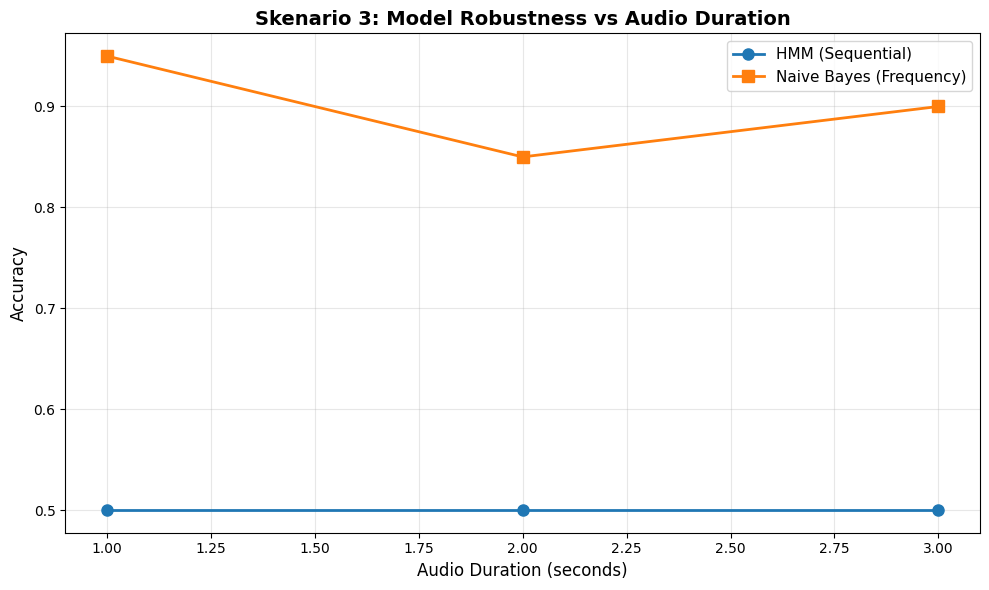

In [ ]:
durations = [1.0, 2.0, 3.0]
results_scenario3 = {'duration': [], 'hmm_accuracy': [], 'nb_accuracy': []}

for duration in durations:
    print(f"Testing with {duration}s audio duration...")
    
    preprocessor_test = AudioPreprocessor(target_length=duration)
    codebook_dur = CodebookGenerator(n_clusters=optimal_clusters)
    
    all_mfcc = []
    for folder, label in train_folders:
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]
        for filename in files:
            filepath = os.path.join(folder, filename)
            try:
                audio_raw, sr = librosa.load(filepath, sr=None, mono=False)
                audio = preprocessor_test.check_and_convert_mono(audio_raw)
                audio = preprocessor_test.check_and_resample(audio, sr)
                audio = preprocessor_test.check_and_trim_silence(audio)
                if len(audio) / preprocessor_test.sr >= 0.5:
                    audio = preprocessor_test.check_and_normalize_amplitude(audio)
                    audio = preprocessor_test.normalize_length(audio)
                    audio = preprocessor_test.apply_pre_emphasis(audio)
                    mfcc = preprocessor_test.extract_mfcc(audio)
                    all_mfcc.append(mfcc)
            except:
                continue
    
    all_mfcc = np.vstack(all_mfcc)
    codebook_dur.kmeans.fit(all_mfcc)
    codebook_dur.is_fitted = True
    
    quantizer_dur = VectorQuantizer(codebook_dur)
    data_prep_dur = DataPreparer(n_symbols=optimal_clusters)
    
    hmm_train_dur = data_prep_dur.prepare_hmm_data(train_folders, quantizer_dur)
    hmm_test_dur = data_prep_dur.prepare_hmm_data(test_folders, quantizer_dur)
    nb_train_dur = data_prep_dur.prepare_nb_data(train_folders, quantizer_dur)
    nb_test_dur = data_prep_dur.prepare_nb_data(test_folders, quantizer_dur)
    
    hmm_clf_dur = HMMClassifier(n_components=5, n_iter=100)
    hmm_clf_dur.train(hmm_train_dur)
    
    nb_clf_dur = NaiveBayesClassifier()
    nb_clf_dur.train(nb_train_dur)
    
    # Predict using DataFrame format
    hmm_pred_dur = hmm_clf_dur.predict_batch(hmm_test_dur)
    nb_pred_dur = nb_clf_dur.predict(nb_test_dur)
    
    hmm_acc_dur = accuracy_score(hmm_test_dur['label'].values, hmm_pred_dur)
    nb_acc_dur = accuracy_score(nb_test_dur['label'].values, nb_pred_dur)
    
    results_scenario3['duration'].append(duration)
    results_scenario3['hmm_accuracy'].append(hmm_acc_dur)
    results_scenario3['nb_accuracy'].append(nb_acc_dur)
    
    print(f"HMM Accuracy: {hmm_acc_dur:.4f} | NB Accuracy: {nb_acc_dur:.4f}\n")

plt.figure(figsize=(10, 6))
plt.plot(results_scenario3['duration'], results_scenario3['hmm_accuracy'], 
         marker='o', linewidth=2, markersize=8, label='HMM (Sequential)')
plt.plot(results_scenario3['duration'], results_scenario3['nb_accuracy'], 
         marker='s', linewidth=2, markersize=8, label='Naive Bayes (Frequency)')
plt.xlabel('Audio Duration (seconds)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Skenario 3: Model Robustness vs Audio Duration', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Analisis Likelihood HMM: Mengapa Selalu Memilih Normal?

Untuk memahami kenapa HMM cenderung memprediksi kelas Normal, kita perlu melihat distribusi likelihood scores dari kedua model (λ_TB dan λ_Normal) pada data test.

ANALISIS LIKELIHOOD: MENGAPA HMM SELALU MEMILIH NORMAL?

1. STATISTIK LIKELIHOOD SCORES
--------------------------------------------------------------------------------
Metric               TB Model             Normal Model         Difference
--------------------------------------------------------------------------------
Mean                 -0.00                0.00                 -0.00
Median               -0.00                0.00                 -0.00
Std Dev              0.00                 0.00                 0.00
Min                  -0.00                0.00                 -0.00
Max                  -0.00                0.00                 -0.00

2. LIKELIHOOD PER TRUE CLASS
--------------------------------------------------------------------------------

True Class: TB (n=10)
  Score TB    - mean: -0.00, std: 0.00
  Score Normal- mean: 0.00, std: 0.00
  Difference  - mean: -0.00, std: 0.00
  Correctly predicted: 0/10 (0.0%)
  Predicted as TB: 0/10 (0.0%)

True Class: NOR

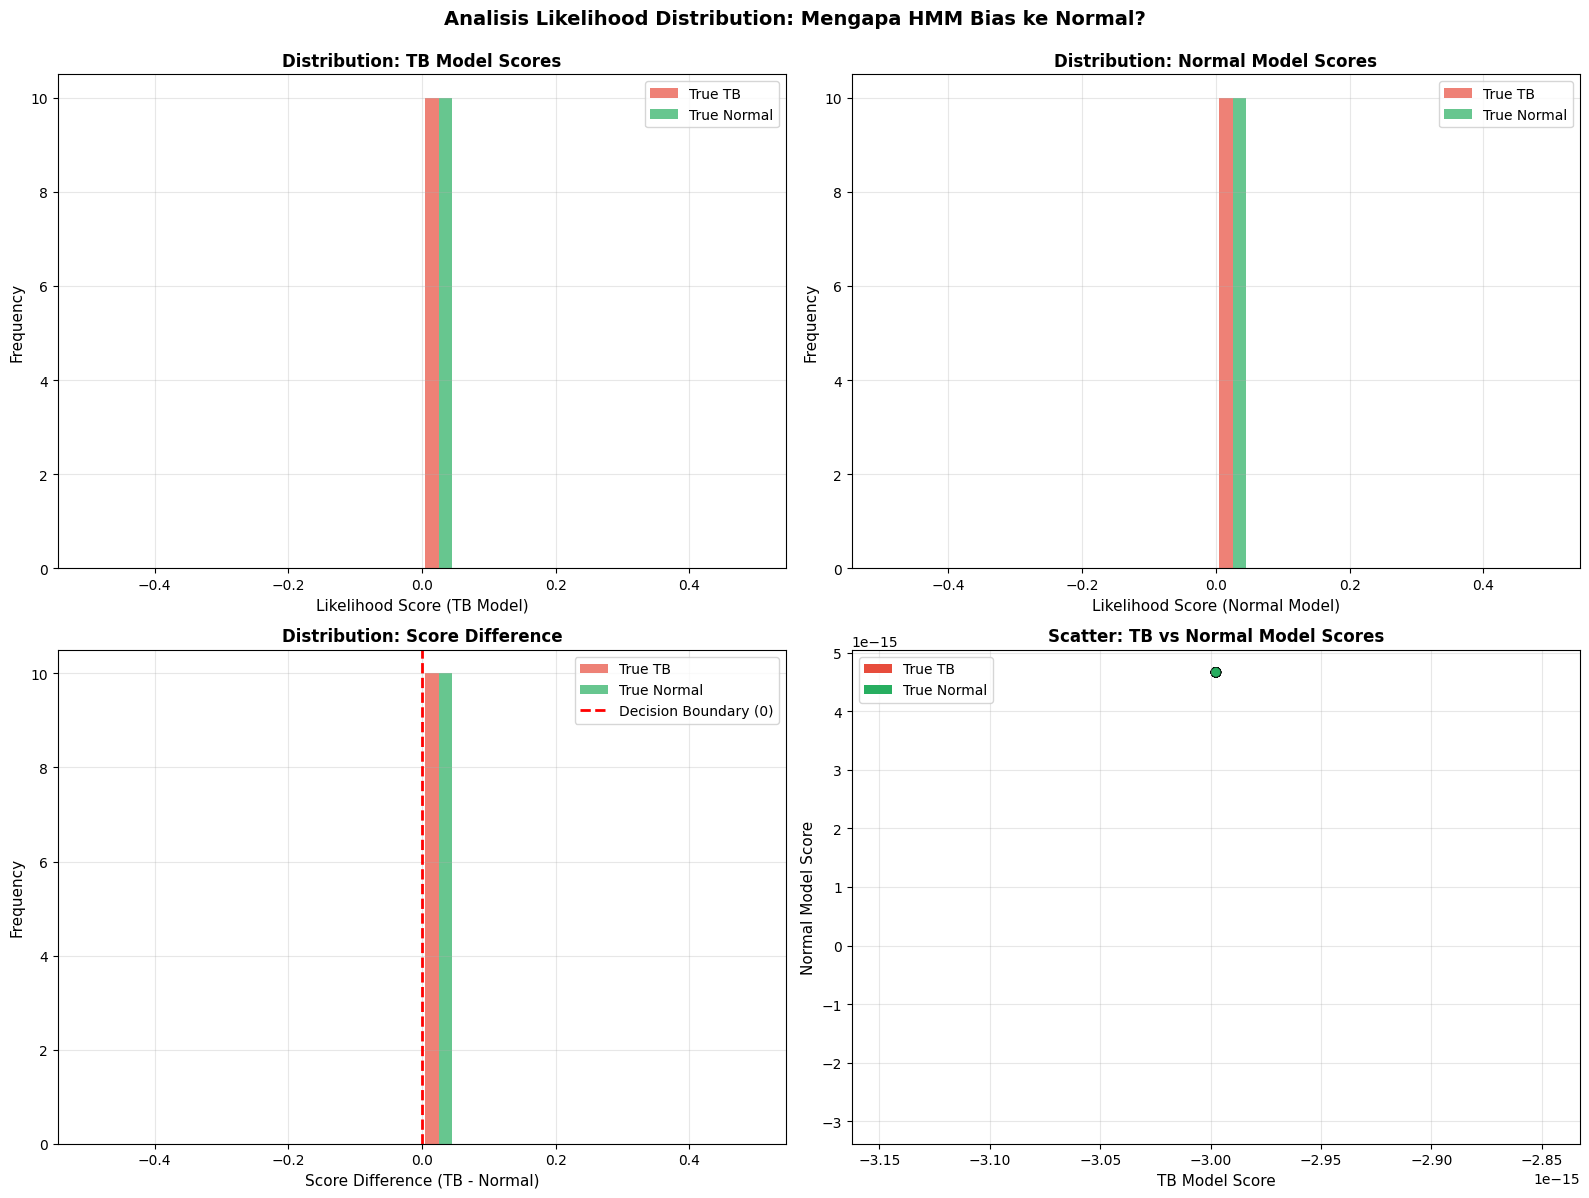


KESIMPULAN DIAGNOSA

MASALAH TERIDENTIFIKASI: Normal Model TERLALU GENEROUS!

Model Normal memberikan likelihood LEBIH TINGGI untuk hampir semua sequences,
termasuk sequences dari kelas TB. Ini menyebabkan HMM selalu memprediksi Normal.

MENGAPA INI TERJADI?
1. Model Normal mungkin terlalu 'liberal' - emission probabilities terlalu uniform
2. Training sequences Normal mungkin lebih beragam, covering lebih banyak patterns
3. Model TB mungkin terlalu 'strict' - hanya fit ke training data TB yang spesifik
4. Kemungkinan ada overlap besar antara acoustic features TB dan Normal

PENYEBAB TEKNIS:
- Normal model startprob atau transmat mungkin lebih tinggi secara average
- Normal model emission probabilities lebih spread out (less peaky)
- TB model mungkin underfit atau stuck di local optima

SOLUSI:
1. Normalisasi likelihood dengan prior probability: P(seq|model) × P(model)
2. Gunakan likelihood ratio test: log(P(seq|TB)) - log(P(seq|Normal))
3. Tambahkan threshold atau calibration pada dec

In [106]:
# ANALISIS LIKELIHOOD DISTRIBUTION

print("="*80)
print("ANALISIS LIKELIHOOD: MENGAPA HMM SELALU MEMILIH NORMAL?")
print("="*80)

# Hitung likelihood untuk semua test samples
likelihood_analysis = []

for idx, row in hmm_test_data.iterrows():
    seq = row['sequence']
    true_label = row['label']
    file_id = row['file_id']
    
    X = np.array(seq).reshape(-1, 1)
    
    try:
        score_tb = hmm_classifier.models['tb'].score(X)
        score_normal = hmm_classifier.models['normal'].score(X)
        
        likelihood_analysis.append({
            'file_id': file_id,
            'true_label': true_label,
            'score_tb': score_tb,
            'score_normal': score_normal,
            'score_diff': score_tb - score_normal,
            'predicted': 'tb' if score_tb > score_normal else 'normal'
        })
    except Exception as e:
        print(f"Error processing {file_id}: {e}")
        continue

df_likelihood = pd.DataFrame(likelihood_analysis)

# 1. STATISTIK LIKELIHOOD
print("\n1. STATISTIK LIKELIHOOD SCORES")
print("-"*80)
print(f"{'Metric':<20} {'TB Model':<20} {'Normal Model':<20} {'Difference'}")
print("-"*80)
print(f"{'Mean':<20} {df_likelihood['score_tb'].mean():<20.2f} {df_likelihood['score_normal'].mean():<20.2f} {df_likelihood['score_diff'].mean():.2f}")
print(f"{'Median':<20} {df_likelihood['score_tb'].median():<20.2f} {df_likelihood['score_normal'].median():<20.2f} {df_likelihood['score_diff'].median():.2f}")
print(f"{'Std Dev':<20} {df_likelihood['score_tb'].std():<20.2f} {df_likelihood['score_normal'].std():<20.2f} {df_likelihood['score_diff'].std():.2f}")
print(f"{'Min':<20} {df_likelihood['score_tb'].min():<20.2f} {df_likelihood['score_normal'].min():<20.2f} {df_likelihood['score_diff'].min():.2f}")
print(f"{'Max':<20} {df_likelihood['score_tb'].max():<20.2f} {df_likelihood['score_normal'].max():<20.2f} {df_likelihood['score_diff'].max():.2f}")

# 2. ANALISIS PER KELAS
print("\n2. LIKELIHOOD PER TRUE CLASS")
print("-"*80)

for true_class in ['tb', 'normal']:
    subset = df_likelihood[df_likelihood['true_label'] == true_class]
    print(f"\nTrue Class: {true_class.upper()} (n={len(subset)})")
    print(f"  Score TB    - mean: {subset['score_tb'].mean():.2f}, std: {subset['score_tb'].std():.2f}")
    print(f"  Score Normal- mean: {subset['score_normal'].mean():.2f}, std: {subset['score_normal'].std():.2f}")
    print(f"  Difference  - mean: {subset['score_diff'].mean():.2f}, std: {subset['score_diff'].std():.2f}")
    
    # Cek berapa yang diprediksi benar
    correct = (subset['predicted'] == subset['true_label']).sum()
    print(f"  Correctly predicted: {correct}/{len(subset)} ({correct/len(subset)*100:.1f}%)")
    
    # Cek apakah ada yang diprediksi TB
    pred_as_tb = (subset['predicted'] == 'tb').sum()
    print(f"  Predicted as TB: {pred_as_tb}/{len(subset)} ({pred_as_tb/len(subset)*100:.1f}%)")

# 3. KASUS SPESIFIK: FILES YANG DIPREDIKSI SALAH
print("\n3. CONTOH KASUS TB YANG SALAH DIPREDIKSI SEBAGAI NORMAL")
print("-"*80)

tb_misclassified = df_likelihood[(df_likelihood['true_label'] == 'tb') & 
                                  (df_likelihood['predicted'] == 'normal')]

print(f"\nTotal TB misclassified: {len(tb_misclassified)}")
print("\nTop 5 worst cases (TB diprediksi Normal dengan margin terbesar):")
print(f"{'File':<35} {'Score TB':<12} {'Score Normal':<12} {'Diff'}")
print("-"*80)

worst_cases = tb_misclassified.nsmallest(5, 'score_diff')
for _, case in worst_cases.iterrows():
    print(f"{case['file_id'][:34]:<35} {case['score_tb']:<12.2f} {case['score_normal']:<12.2f} {case['score_diff']:.2f}")

# 4. VISUALISASI DISTRIBUSI LIKELIHOOD
print("\n4. VISUALISASI DISTRIBUSI LIKELIHOOD")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Likelihood TB model untuk kedua kelas
tb_true_tb = df_likelihood[df_likelihood['true_label'] == 'tb']['score_tb']
tb_true_normal = df_likelihood[df_likelihood['true_label'] == 'normal']['score_tb']

axes[0, 0].hist([tb_true_tb, tb_true_normal], bins=20, alpha=0.7, label=['True TB', 'True Normal'], color=['#E74C3C', '#27AE60'])
axes[0, 0].set_xlabel('Likelihood Score (TB Model)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution: TB Model Scores', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Likelihood Normal model untuk kedua kelas
normal_true_tb = df_likelihood[df_likelihood['true_label'] == 'tb']['score_normal']
normal_true_normal = df_likelihood[df_likelihood['true_label'] == 'normal']['score_normal']

axes[0, 1].hist([normal_true_tb, normal_true_normal], bins=20, alpha=0.7, label=['True TB', 'True Normal'], color=['#E74C3C', '#27AE60'])
axes[0, 1].set_xlabel('Likelihood Score (Normal Model)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution: Normal Model Scores', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Score Difference (TB - Normal)
diff_true_tb = df_likelihood[df_likelihood['true_label'] == 'tb']['score_diff']
diff_true_normal = df_likelihood[df_likelihood['true_label'] == 'normal']['score_diff']

axes[1, 0].hist([diff_true_tb, diff_true_normal], bins=20, alpha=0.7, label=['True TB', 'True Normal'], color=['#E74C3C', '#27AE60'])
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary (0)')
axes[1, 0].set_xlabel('Score Difference (TB - Normal)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution: Score Difference', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scatter plot TB vs Normal scores
colors = ['#E74C3C' if label == 'tb' else '#27AE60' for label in df_likelihood['true_label']]
axes[1, 1].scatter(df_likelihood['score_tb'], df_likelihood['score_normal'], 
                   c=colors, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1, 1].plot([df_likelihood['score_tb'].min(), df_likelihood['score_tb'].max()],
                [df_likelihood['score_tb'].min(), df_likelihood['score_tb'].max()],
                'r--', linewidth=2, label='Equal Score Line')
axes[1, 1].set_xlabel('TB Model Score', fontsize=11)
axes[1, 1].set_ylabel('Normal Model Score', fontsize=11)
axes[1, 1].set_title('Scatter: TB vs Normal Model Scores', fontsize=12, fontweight='bold')
axes[1, 1].legend(['Equal Score', 'True TB', 'True Normal'])
axes[1, 1].grid(True, alpha=0.3)

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', label='True TB'),
                   Patch(facecolor='#27AE60', label='True Normal')]
axes[1, 1].legend(handles=legend_elements, loc='upper left')

plt.suptitle('Analisis Likelihood Distribution: Mengapa HMM Bias ke Normal?', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 5. KESIMPULAN
print("\n" + "="*80)
print("KESIMPULAN DIAGNOSA")
print("="*80)

mean_diff_tb = df_likelihood[df_likelihood['true_label'] == 'tb']['score_diff'].mean()
mean_diff_normal = df_likelihood[df_likelihood['true_label'] == 'normal']['score_diff'].mean()

if mean_diff_tb < 0 and mean_diff_normal < 0:
    print("""
MASALAH TERIDENTIFIKASI: Normal Model TERLALU GENEROUS!

Model Normal memberikan likelihood LEBIH TINGGI untuk hampir semua sequences,
termasuk sequences dari kelas TB. Ini menyebabkan HMM selalu memprediksi Normal.

MENGAPA INI TERJADI?
1. Model Normal mungkin terlalu 'liberal' - emission probabilities terlalu uniform
2. Training sequences Normal mungkin lebih beragam, covering lebih banyak patterns
3. Model TB mungkin terlalu 'strict' - hanya fit ke training data TB yang spesifik
4. Kemungkinan ada overlap besar antara acoustic features TB dan Normal

PENYEBAB TEKNIS:
- Normal model startprob atau transmat mungkin lebih tinggi secara average
- Normal model emission probabilities lebih spread out (less peaky)
- TB model mungkin underfit atau stuck di local optima

SOLUSI:
1. Normalisasi likelihood dengan prior probability: P(seq|model) × P(model)
2. Gunakan likelihood ratio test: log(P(seq|TB)) - log(P(seq|Normal))
3. Tambahkan threshold atau calibration pada decision boundary
4. Re-train dengan hyperparameter berbeda (lebih banyak states, iterasi)
5. Gunakan discriminative training (bukan generative per-class)
    """)
elif mean_diff_tb > 0 and mean_diff_normal < 0:
    print("\nMODEL HMM BEKERJA DENGAN BAIK!")
    print("TB sequences cenderung mendapat score lebih tinggi dari TB model,")
    print("dan Normal sequences cenderung mendapat score lebih tinggi dari Normal model.")
else:
    print(f"\nKONDISI TIDAK JELAS:")
    print(f"  Mean diff untuk True TB: {mean_diff_tb:.2f}")
    print(f"  Mean diff untuk True Normal: {mean_diff_normal:.2f}")
    print("  Perlu investigasi lebih lanjut pada model parameters dan training process.")

print("="*80)